# Set To Be Fair: Set-Valued Classification Under Fairness Constraints

### Imports

In [1]:
import numpy as np
import scipy
from scipy import stats
from scipy.stats import norm
from scipy.stats import multivariate_normal as mvnorm
from scipy import optimize
from scipy.optimize import minimize
from scipy.stats import ecdf
from time import time
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split

## Simulated Data - Without estimating the $p_k$'s

### Data Generation

We simulate data hierarchicaly, by first generating $Y$, then $S|Y=k$ and finally $X|S = s, Y = k$.
The model is:
\begin{align*}
    Y &\sim \mathcal{U}([K])\\
    S|Y=k &\sim 2\times\mathcal{Ber}(\frac{1}{2}+\frac{(2(u \% 2)-1)K}{(2*(u + K))})-1\\
    X|S=s, Y=k &\sim \mathcal{N}(k \mu s, I_d),
\end{align*}
where $\mu \sim \mathcal{U}([0,1]^d)$.

In [36]:
# parameters
SampleNew=10000
Nrep = 10
beta_step = 4

dimX = 5
muVec  = np.random.uniform(0, 1, size = dimX)
sigma = np.identity(len(muVec))
K = 4
pY = [0.04,0.2,0.2,0.56]#np.ones(K)/K
print(pY)
sampleSize = 5000
u = np.linspace(1,K,K)
print(u)
pSgivenY = (1/2+(2*(u % 2)-1)*K/(2*(u + K)))/3
print(pSgivenY)
print(np.mean(pSgivenY))

[0.04, 0.2, 0.2, 0.56]
[1. 2. 3. 4.]
[0.3        0.05555556 0.26190476 0.08333333]
0.17519841269841271


In [ ]:
# sample generation function
def getSample(sampleSize, muVec, sigma, K, pY):
    Y = np.random.choice(a = range(1,K+1), size = sampleSize, replace = True, p = pY)
    piSgivenY = (1/2+(2*(Y % 2)-1)*K/(2*(Y+K)))
    S =(2*np.random.binomial(n = 1, p = piSgivenY, size = sampleSize)-1)
    X = np.zeros((sampleSize, len(muVec)))
    for k in range(1, K+1):
        for s in [-1,1]:
            X[(Y == k)&(S == s), ] = mvnorm.rvs(mean = k*muVec*s, cov = sigma, size = np.sum((Y == k)&(S == s)))

    return(X,S,Y)

Therefore, we compute the $p_k$ functions as:
\begin{equation*}
    p_k(x,s) = \mathbb{P}(S=s|Y=k) \mathbb{P}(Y=k|X=x, S=s),
\end{equation*}
which we then normalize to sum to 1.

In [ ]:
# function to compute the exact scores (no estimation) - pk(X,s)
def ScoreMixture(X, S, muVec, sigma, K, pY, pSgivenY):
    scoreBayes = np.zeros((np.shape(X)[0], K))
    for k in range(0,K):
        scoreBayes[:,k] = pY[k]*(pSgivenY[k]*mvnorm.pdf(X, mean = (k+1)*muVec*1, cov = sigma)*(S == 1) + (1-pSgivenY[k])*mvnorm.pdf(X, mean = (k+1)*muVec*(-1), cov = sigma)*(S == -1))
    scoreBayes = np.transpose(np.transpose(scoreBayes)/np.sum(scoreBayes,axis = 1))
    return(scoreBayes)


### Set-Valued (Unfair) Classifier

The (unfair) set-valued classifier under mean size constraint, from [Denis and Hebiri 2017](http://www.jmlr.org/papers/v18/16-596.html).

\begin{equation*}
    \Gamma_\beta(x,s) = \left\{ k \in [K]: p_k(x,s)\geq G^{-1}(\beta) \right\},
\end{equation*}
where $G(t) = \underset{k \in [K]}{\sum} 1 - F_{p_k}(t)$.

In [107]:
riskBayes = np.zeros(Nrep)
risks = []
risks_mean = []
risk = np.zeros(Nrep)
sizes = []
sizes_mean = []
ExpSize = np.zeros(Nrep)
unfairnesses = []
unfairnesses_mean = []
unfairness = np.zeros(Nrep)
risk_bayes_mean = []
risks_bayes = []
unfair_time = []
unfair_time_mean = []

for b in range(1, beta_step*K+1):
    risks.append([])
    sizes.append([])
    unfairnesses.append([])
    risks_bayes.append([])
    unfair_time.append([])
    beta = b/beta_step
    for m in range(0,Nrep):
        
        X,S,Y = getSample(sampleSize, muVec, sigma, K, pY)
        scoreBayes = ScoreMixture(X, S, muVec, sigma, K, pY, pSgivenY)

        Xvalid,Svalid,Yvalid = getSample(10000, muVec, sigma, K, pY)
        scoreValid = ScoreMixture(Xvalid, Svalid, muVec, sigma, K, pY, pSgivenY)

        pred = np.argmax(scoreValid, axis = 1)+1
        riskBayes[m] = np.mean(pred != Yvalid)
        
        a = time()
        threshold = np.quantile(scoreBayes, 1-beta/K)
        b = time()
        unfair_time[-1].append(b-a)
        
        matSetValued = (scoreValid >= threshold)
        risk[m] = 1-np.mean(matSetValued[range(0,10000),(Yvalid-1)])
        ExpSize[m] = np.mean(np.sum(matSetValued,axis = 1))

        unfairness[m] = np.max(np.abs(np.mean(matSetValued[Svalid == 1,:], axis = 0)- np.mean(matSetValued[Svalid == -1,:], axis = 0)))

        risks[-1].append(risk[m])
        sizes[-1].append(ExpSize[m])
        unfairnesses[-1].append(unfairness[m])
        risks_bayes[-1].append(riskBayes[m])
    risks_mean.append(np.mean(risks[-1]))
    sizes_mean.append(np.mean(sizes[-1]))
    unfairnesses_mean.append(np.mean(unfairnesses[-1]))
    risk_bayes_mean.append(np.mean(risks_bayes[-1]))
    unfair_time_mean.append(np.mean(unfair_time))


### DP-Fair TOP-1 Classifier

In [108]:
lamb0 = np.array([np.log(1/K) for _ in range(K)])
# gamma0 = np.random.uniform(0, 1, size=K)
# initialGuess = np.concatenate([lamb0,gamma0])
initialGuess = lamb0

# riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
# risk_bayes_mean = []
# risks_bayes = []

risk = np.zeros(Nrep)
# ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair_top_1 = []
risks_fair_mean_top_1 = []
# sizes_fair = []
# sizes_fair_mean = []
unfairnesses_fair_top_1 = []
unfairness_fair_mean_top_1 = []

for b in range(1, beta_step*K+1):
    risks_fair_top_1.append([])
    # sizes_fair.append([])
    unfairnesses_fair_top_1.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = param
        out = np.sum(np.mean(np.max(np.mean(S==1)*scoreBayes[S==1,]-lamb,  
                    axis = 1))
                    +np.mean(np.max(np.mean(S==-1)*scoreBayes[S==-1,]+lamb, axis = 1)))
        return(out)

    for m in range(Nrep):

        X,S,Y = getSample(sampleSize, muVec, sigma, K, pY)

        Xvalid,Svalid,Yvalid = getSample(1000, muVec, sigma, K, pY)
        scoreBayes = ScoreMixture(X, S, muVec, sigma, K, pY, pSgivenY)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = paramEstim.x
        # tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        # ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)

        scoreNew = ScoreMixture(Xvalid, Svalid, muVec, sigma, K, pY, pSgivenY)
        fair_top_1  = np.zeros(len(Svalid))
        # matSetValuedFair[Svalid==1, ] = (scoreNew[Svalid==1,]>= tt1)
        # matSetValuedFair[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= ttm1)
        fair_top_1[Svalid==1] = np.argmax(np.mean(S==1)*scoreNew[Svalid==1,] - lambStar, axis = 1).astype(int)
        fair_top_1[Svalid==-1] = np.argmax(np.mean(S==-1)*scoreNew[Svalid==-1,] + lambStar, axis = 1).astype(int)
        # print(fair_top_1)
        # ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.abs(np.max([np.mean(fair_top_1[Svalid==1]==k) for k in range(K)]) - np.max([np.mean(fair_top_1[Svalid==-1]==k) for k in range(K)]))
        risk[m] = np.mean(fair_top_1!=(Yvalid - 1))

        risks_fair_top_1[-1].append(risk[m])
    #     sizes_fair[-1].append(ExpSize[m])
        unfairnesses_fair_top_1[-1].append(unfairness[m])
    risks_fair_mean_top_1.append(np.mean(risks_fair_top_1[-1]))
    # sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean_top_1.append(np.mean(unfairnesses_fair_top_1[-1]))

### Fair Set-Valued Classifier (Solver)

We use the $\texttt{minimize}$ with the L-BFGS-B method to solve for $\lambda$ and $\alpha$.

In [109]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size = K)
initialGuess = np.concatenate([lamb0,gamma0])
risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair = []
risks_fair_mean = []
sizes_fair = []
sizes_fair_mean = []
unfairnesses_fair = []
unfairness_fair_mean = []
fair_time = []
fair_time_mean = []

for b in range(1, beta_step*K+1):
    risks_fair.append([])
    sizes_fair.append([])
    unfairnesses_fair.append([])
    fair_time.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = np.exp(param[0])
        gamma = param[1:(K+1)]
        out = np.sum(np.mean(np.maximum(np.mean(S == 1)*(scoreBayes[S == 1,]-lamb)-gamma,0), axis = 0)
                +np.mean(np.maximum(np.mean(S == -1)*(scoreBayes[S == -1,]-lamb)+gamma,0), axis = 0)) +lamb*beta
        return(out)
    
    for m in range(Nrep):

        X,S,Y = getSample(sampleSize, muVec, sigma, K, pY)
        scoreBayes = ScoreMixture(X, S, muVec, sigma, K, pY, pSgivenY)
        
        a = time()
        paramEstim = minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")
        b = time()
        fair_time[-1].append(b-a)

        lambStar = np.exp(paramEstim.x[0])
        tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)


        Xnew,Snew,Ynew = getSample(SampleNew, muVec, sigma, K, pY)
        scoreNew = ScoreMixture(Xnew, Snew, muVec, sigma, K, pY, pSgivenY)
        matSetValuedFair  = np.zeros((SampleNew,K))
        matSetValuedFair[Snew == 1, ]  = (scoreNew[Snew == 1,]>= tt1)
        matSetValuedFair[Snew == -1, ]  = (scoreNew[Snew == -1,]>= ttm1)

        
        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Snew == 1,:], axis=0)- np.mean(matSetValuedFair[Snew == -1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[range(0,SampleNew),(Ynew-1)])

        risks_fair[-1].append(risk[m])
        sizes_fair[-1].append(ExpSize[m])
        unfairnesses_fair[-1].append(unfairness[m])
    risks_fair_mean.append(np.mean(risks_fair[-1]))
    sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean.append(np.mean(unfairnesses_fair[-1]))
    fair_time_mean.append(np.mean(fair_time[-1]))

### Fair Set-Valued Classifier (Two-Step Method)

Here, we use the two-step method, fixing $\forall k \in [K]: \beta_k = \mathbb{P}(k \in \Gamma_\beta)$ and then $\Gamma_{\beta, fair} = \left\{k \in [K]: p_k(x,s) \geq 1 - F_{p_k,s}^{-1}(\beta_k)\right\}$.

In [110]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])
risk_v2 = np.zeros(Nrep)
ExpSize_v2 = np.zeros(Nrep)
unfairness_v2 = np.zeros(Nrep)

risks_fair_v2 = []
risks_fair_mean_v2 = []
sizes_fair_v2 = []
sizes_fair_mean_v2 = []
unfairnesses_fair_v2 = []
unfairness_fair_mean_v2 = []
fair_time_v2 = []
fair_time_mean_v2 = []


for b in range(1, beta_step*K+1):
    risks_fair_v2.append([])
    sizes_fair_v2.append([])
    unfairnesses_fair_v2.append([])
    fair_time_v2.append([])
    beta = b/beta_step

    for m in range(Nrep):
        X_pk,S_pk,Y_pk = getSample(int(sampleSize/2), muVec, sigma, K, pY)
        X,S,Y = getSample(int(sampleSize/2), muVec, sigma, K, pY)

        scoreBayes = ScoreMixture(X, S, muVec, sigma, K, pY, pSgivenY)

        a = time()
        threshold = np.quantile(scoreBayes, 1-beta/K)

        T = np.mean(scoreBayes <= threshold, axis = 0)
        tt1 = np.diag(np.quantile(scoreBayes[S == 1,],T, axis = 0))
        ttm1 = np.diag(np.quantile(scoreBayes[S == -1,],T, axis =0))
        b = time()
        fair_time_v2[-1].append(b-a)

        Xvalid,Svalid,Yvalid = getSample(SampleNew, muVec, sigma, K, pY)

        scorevalid = ScoreMixture(Xvalid, Svalid, muVec, sigma, K, pY, pSgivenY)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid == 1, ] = (scorevalid[Svalid == 1,]>= tt1)
        matSetValuedFair[Svalid == -1, ] = (scorevalid[Svalid == -1,]>= ttm1)

        ExpSize_v2[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness_v2[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk_v2[m] = 1-np.mean(matSetValuedFair[range(len(Svalid)),Yvalid-1])

        risks_fair_v2[-1].append(risk_v2[m])
        sizes_fair_v2[-1].append(ExpSize_v2[m])
        unfairnesses_fair_v2[-1].append(unfairness_v2[m])
    risks_fair_mean_v2.append(np.mean(risks_fair_v2[-1]))
    sizes_fair_mean_v2.append(np.mean(sizes_fair_v2[-1]))
    unfairness_fair_mean_v2.append(np.mean(unfairnesses_fair_v2[-1]))
    fair_time_mean_v2.append(np.mean(fair_time_v2[-1]))

### Comparison Between Unfair and Fair SVC

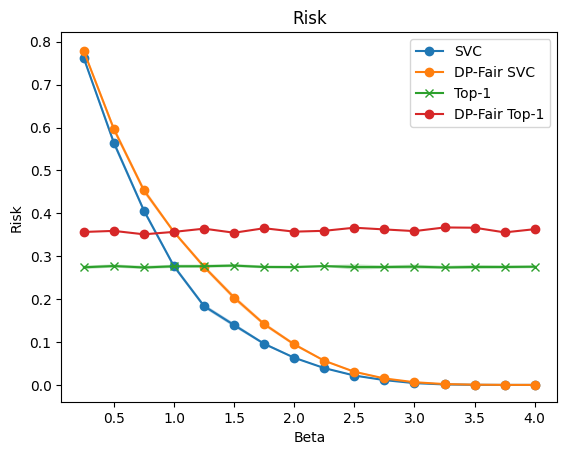

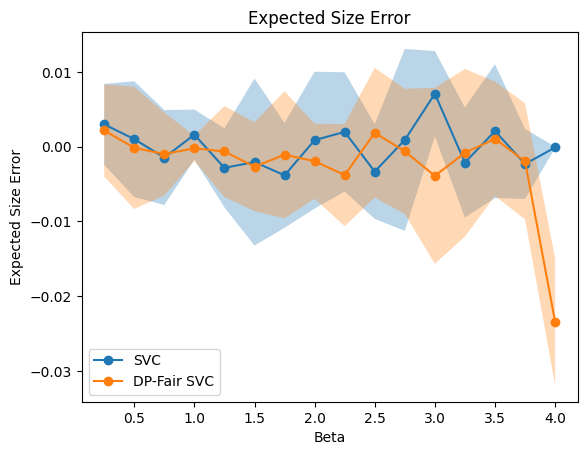

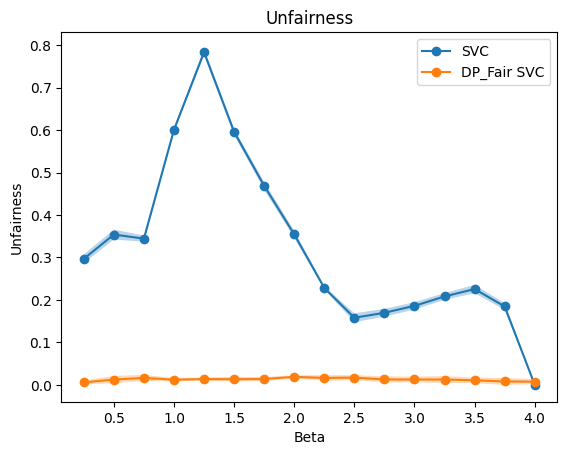

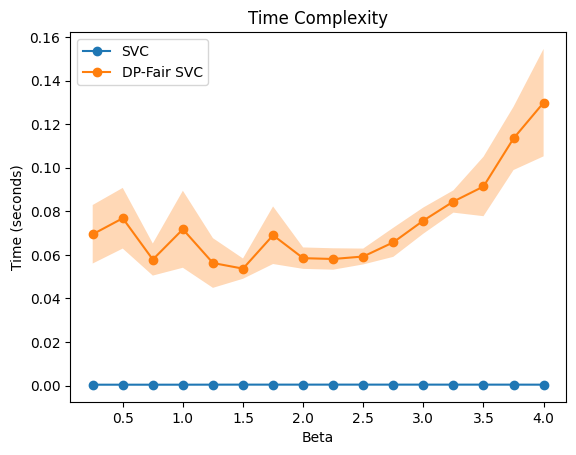

In [111]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risk_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_mean)-np.std(risks, axis=1), np.array(risks_mean)+np.std(risks, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risk_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risk_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes, axis=1), np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairnesses_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairnesses_mean)-np.std(unfairnesses, axis=1), np.array(unfairnesses_mean)+np.std(unfairnesses, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfair_time_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, fair_time_mean, label='DP-Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfair_time_mean)-np.std(unfair_time, axis=1), np.array(unfair_time_mean)+np.std(unfair_time, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(fair_time_mean)-np.std(fair_time, axis=1), np.array(fair_time_mean)+np.std(fair_time, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Time (seconds)')
plt.title('Time Complexity')
plt.legend()
plt.show()

### Comparison Between Solver and Two-Step Methods

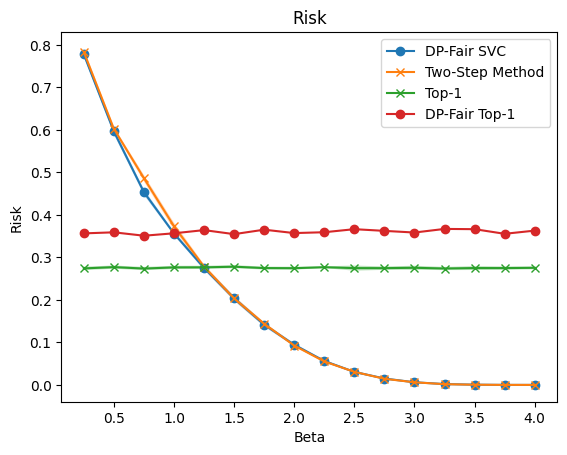

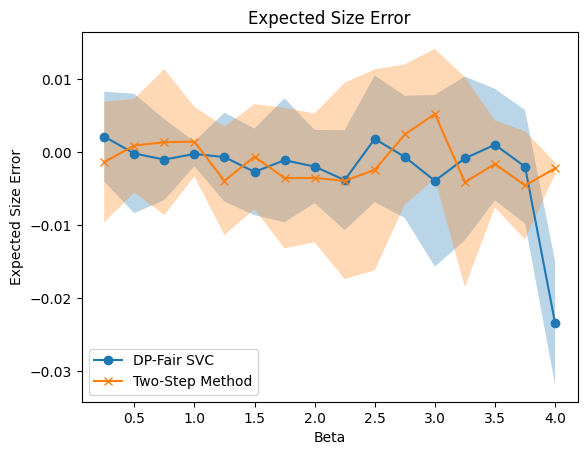

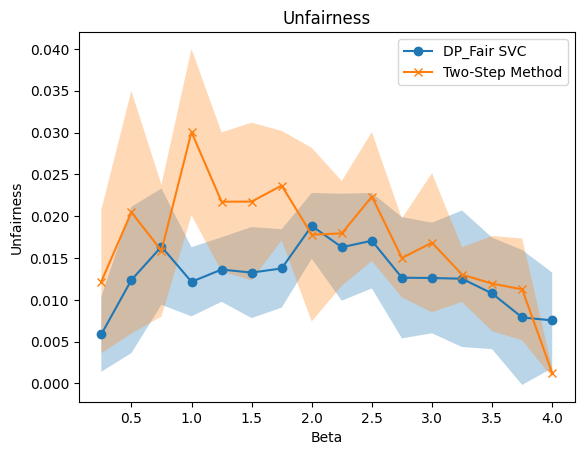

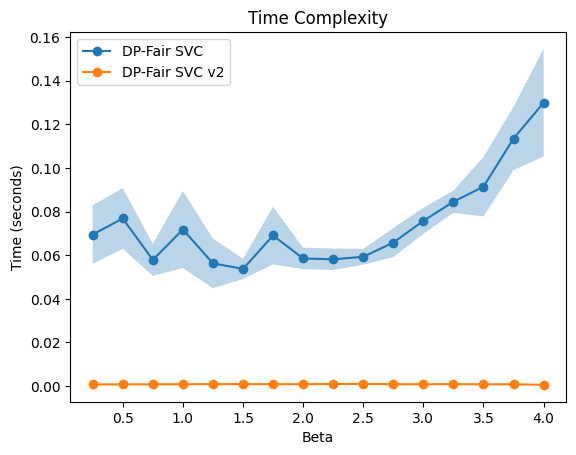

In [112]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_v2, label='Two-Step Method', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risk_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean_v2)-np.std(risks_fair_v2, axis=1), np.array(risks_fair_mean_v2)+np.std(risks_fair_v2, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risk_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risk_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair_v2, axis=1), np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean_v2, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean_v2)-np.std(unfairnesses_fair_v2, axis=1), np.array(unfairness_fair_mean_v2)+np.std(unfairnesses_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, fair_time_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, fair_time_mean_v2, label='DP-Fair SVC v2', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(fair_time_mean)-np.std(fair_time, axis=1), np.array(fair_time_mean)+np.std(fair_time, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(fair_time_mean_v2)-np.std(fair_time_v2, axis=1), np.array(fair_time_mean_v2)+np.std(fair_time_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Time (seconds)')
plt.title('Time Complexity')
plt.legend()
plt.show()

## Simulated Data - Estimating the $p_k$'s using a GradientBoostingClassifier

In [ ]:
# function to compute the scores (with estimation) - pk(X,s)
def ScoreMixture(X, S, estimator, noise = True, *args):
    data = np.concatenate((X, S.reshape(-1, 1)), axis=1)
    if noise:
        return estimator.predict_proba(data) + np.random.uniform(2e-7, size=(data.shape[0], estimator.n_classes_))
    return estimator.predict_proba(data)

### TOP-1 Classifier

In [ ]:
lamb0 = np.array([np.log(1/K) for _ in range(K)])
# gamma0 = np.random.uniform(0, 1, size=K)
# initialGuess = np.concatenate([lamb0,gamma0])
initialGuess = lamb0

riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
risk_bayes_mean = []
risks_bayes = []

estimator = GradientBoostingClassifier(n_estimators=50)

risk = np.zeros(Nrep)
# ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)


for b in range(1, beta_step*K+1):
    risks_bayes.append([])
    # unfairnesses_fair_top_1.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = param
        out = np.sum(np.mean(np.max(np.mean(S==1)*scoreBayes[S==1,]-lamb,  
                    axis = 1))
                    +np.mean(np.max(np.mean(S==-1)*scoreBayes[S==-1,]+lamb, axis = 1)))
        return(out)

    for m in range(Nrep):

        X_pk,S_pk,Y_pk = getSample(int(sampleSize/2), muVec, sigma, K, pY)
        X,S,Y = getSample(int(sampleSize/2), muVec, sigma, K, pY)

        Xvalid,Svalid,Yvalid = getSample(1000, muVec, sigma, K, pY)

        data = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data, Y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = paramEstim.x

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        top_1  = np.zeros(len(Svalid))
        top_1[Svalid==1] = np.argmax(scoreNew[Svalid==1,], axis = 1).astype(int)
        top_1[Svalid==-1] = np.argmax(scoreNew[Svalid==-1,], axis = 1).astype(int)
        unfairness[m] = np.abs(np.max([np.mean(top_1[Svalid==1]==k) for k in range(K)]) - np.max([np.mean(top_1[Svalid==-1]==k) for k in range(K)]))
        risk[m] = np.mean(top_1!=(Yvalid-1))
        risks_bayes[-1].append(risk[m])
        # unfairnesses_fair_top_1[-1].append(unfairness[m])
    risk_bayes_mean.append(np.mean(risks_bayes[-1]))


### DP-Fair TOP-1 Classifier

In [ ]:
lamb0 = np.array([np.log(1/K) for _ in range(K)])
# gamma0 = np.random.uniform(0, 1, size=K)
# initialGuess = np.concatenate([lamb0,gamma0])
initialGuess = lamb0

# riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
# risk_bayes_mean = []
# risks_bayes = []

estimator = GradientBoostingClassifier(n_estimators=50)

risk = np.zeros(Nrep)
# ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair_top_1 = []
risks_fair_mean_top_1 = []
# sizes_fair = []
# sizes_fair_mean = []
unfairnesses_fair_top_1 = []
unfairness_fair_mean_top_1 = []

for b in range(1, beta_step*K+1):
    risks_fair_top_1.append([])
    # sizes_fair.append([])
    unfairnesses_fair_top_1.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = param
        out = np.sum(np.mean(np.max(np.mean(S==1)*scoreBayes[S==1,]-lamb,  
                    axis = 1))
                    +np.mean(np.max(np.mean(S==-1)*scoreBayes[S==-1,]+lamb, axis = 1)))
        return(out)

    for m in range(Nrep):

        X_pk,S_pk,Y_pk = getSample(int(sampleSize/2), muVec, sigma, K, pY)
        X,S,Y = getSample(int(sampleSize/2), muVec, sigma, K, pY)

        Xvalid,Svalid,Yvalid = getSample(1000, muVec, sigma, K, pY)

        data = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data, Y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = paramEstim.x
        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        fair_top_1  = np.zeros(len(Svalid))
        fair_top_1[Svalid==1] = np.argmax(np.mean(S==1)*scoreNew[Svalid==1,] - lambStar, axis = 1).astype(int)
        fair_top_1[Svalid==-1] = np.argmax(np.mean(S==-1)*scoreNew[Svalid==-1,] + lambStar, axis = 1).astype(int)
        unfairness[m] = np.abs(np.max([np.mean(fair_top_1[Svalid==1]==k) for k in range(K)]) - np.max([np.mean(fair_top_1[Svalid==-1]==k) for k in range(K)]))
        risk[m] = np.mean(fair_top_1!=(Yvalid-1))
        risks_fair_top_1[-1].append(risk[m])
        unfairnesses_fair_top_1[-1].append(unfairness[m])
    risks_fair_mean_top_1.append(np.mean(risks_fair_top_1[-1]))

Set-Valued Classifier (Unfair)

In [ ]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks = []
risks_mean = []
sizes = []
sizes_mean = []
unfairnesses = []
unfairness_mean = []

for b in range(1, beta_step*K+1):
    risks.append([])
    sizes.append([])
    unfairnesses.append([])
    beta = b/beta_step

    for m in range(Nrep):

        X_pk,S_pk,Y_pk = getSample(int(sampleSize/2), muVec, sigma, K, pY)
        X,S,Y = getSample(int(sampleSize/2), muVec, sigma, K, pY)
        
        data = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data, Y_pk)

        scoreBayes = ScoreMixture(X, S, estimator)
        threshold = np.quantile(scoreBayes, 1-beta/K)

        T = np.mean(scoreBayes <= threshold, axis = 0)
        # tt1 = np.diag(np.quantile(scoreBayes[S==1,],T, axis = 0))
        # ttm1 = np.diag(np.quantile(scoreBayes[S==-1,],T, axis =0))
        tt1=threshold
        ttm1=threshold

        Xvalid,Svalid,Yvalid = getSample(SampleNew, muVec, sigma, K, pY)

        scorevalid = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scorevalid[Svalid==1,] >= tt1)
        matSetValuedFair[Svalid==-1, ] = (scorevalid[Svalid==-1,] >= ttm1)

        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[range(len(Svalid)),Yvalid-1])

        risks[-1].append(risk[m])
        sizes[-1].append(ExpSize[m])
        unfairnesses[-1].append(unfairness[m])
    risks_mean.append(np.mean(risks[-1]))
    sizes_mean.append(np.mean(sizes[-1]))
    unfairness_mean.append(np.mean(unfairnesses[-1]))

### Fair Set-Valued Classifier (Solver)

In [ ]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])
risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair = []
risks_fair_mean = []
sizes_fair = []
sizes_fair_mean = []
unfairnesses_fair = []
unfairness_fair_mean = []


estimator = GradientBoostingClassifier(n_estimators=50)

def softplus(x, temp=1):
    """Softplus function with temperature scaling to avoid overflow."""
    return np.log1p(np.exp(x * temp)) / temp

for b in range(1, beta_step*K+1):
    risks_fair.append([])
    sizes_fair.append([])
    unfairnesses_fair.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = np.exp(param[0])
        gamma = param[1:(K+1)]
        out = np.sum(np.mean(np.maximum(np.mean(S==1)*(scoreBayes[S==1,]-lamb)-gamma,0), axis = 0)
                +np.mean(np.maximum(np.mean(S==-1)*(scoreBayes[S==-1,]-lamb)+gamma,0), axis =0)) +lamb*beta
        return(out)

    for m in range(Nrep):
        X_pk,S_pk,Y_pk = getSample(int(sampleSize/2), muVec, sigma, K, pY)
        X,S,Y = getSample(int(sampleSize/2), muVec, sigma, K, pY)

        data = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data, Y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = np.exp(paramEstim.x[0])
        tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)


        Xnew,Snew,Ynew = getSample(SampleNew, muVec, sigma, K, pY)
        scoreNew = ScoreMixture(Xnew, Snew, estimator)
        matSetValuedFair  = np.zeros((SampleNew,K))
        matSetValuedFair[Snew==1, ]  = (scoreNew[Snew==1,]>= tt1)
        matSetValuedFair[Snew==-1, ]  = (scoreNew[Snew==-1,]>= ttm1)

        
        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Snew==1,:], axis=0)- np.mean(matSetValuedFair[Snew==-1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[range(0,SampleNew),(Ynew-1)])

        risks_fair[-1].append(risk[m])
        sizes_fair[-1].append(ExpSize[m])
        unfairnesses_fair[-1].append(unfairness[m])
    risks_fair_mean.append(np.mean(risks_fair[-1]))
    sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean.append(np.mean(unfairnesses_fair[-1]))

### Fair Set-Valued Classifier (Two-Step Method)

In [ ]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk_v2 = np.zeros(Nrep)
ExpSize_v2 = np.zeros(Nrep)
unfairness_v2 = np.zeros(Nrep)

risks_fair_v2 = []
risks_fair_mean_v2 = []
sizes_fair_v2 = []
sizes_fair_mean_v2 = []
unfairnesses_fair_v2 = []
unfairness_fair_mean_v2 = []

for b in range(1, beta_step*K+1):
    risks_fair_v2.append([])
    sizes_fair_v2.append([])
    unfairnesses_fair_v2.append([])
    beta = b/beta_step

    for m in range(Nrep):

        X_pk,S_pk,Y_pk = getSample(int(sampleSize/2), muVec, sigma, K, pY)
        X,S,Y = getSample(int(sampleSize/2), muVec, sigma, K, pY)
        
        data = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data, Y_pk)

        scoreBayes = ScoreMixture(X, S, estimator)
        threshold = np.quantile(scoreBayes, 1-beta/K)

        T = np.mean(scoreBayes <= threshold, axis = 0)
        tt1 = np.diag(np.quantile(scoreBayes[S==1,],T, axis = 0))
        ttm1 = np.diag(np.quantile(scoreBayes[S==-1,],T, axis =0))

        Xvalid,Svalid,Yvalid = getSample(SampleNew, muVec, sigma, K, pY)

        scorevalid = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scorevalid[Svalid==1,] >= tt1)
        matSetValuedFair[Svalid==-1, ] = (scorevalid[Svalid==-1,] >= ttm1)

        ExpSize_v2[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness_v2[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk_v2[m] = 1-np.mean(matSetValuedFair[range(len(Svalid)),Yvalid-1])

        risks_fair_v2[-1].append(risk_v2[m])
        sizes_fair_v2[-1].append(ExpSize_v2[m])
        unfairnesses_fair_v2[-1].append(unfairness_v2[m])
    risks_fair_mean_v2.append(np.mean(risks_fair_v2[-1]))
    sizes_fair_mean_v2.append(np.mean(sizes_fair_v2[-1]))
    unfairness_fair_mean_v2.append(np.mean(unfairnesses_fair_v2[-1]))

### Comparison Between Unfair and Fair SVC

In [ ]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risk_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_mean)-np.std(risks, axis=1), np.array(risks_mean)+np.std(risks, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risk_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risk_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean_top_1)-np.std(risks_fair_top_1, axis=1), np.array(risks_fair_mean_top_1)+np.std(risks_fair_top_1, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes, axis=1), np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_mean)-np.std(unfairnesses, axis=1), np.array(unfairness_mean)+np.std(unfairnesses, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()
# plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfair_time_mean, label='SVC', marker='o')
# plt.plot(np.arange(1, beta_step*K+1)/beta_step, fair_time_mean, label='DP-Fair SVC', marker='o')
# plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfair_time_mean)-np.std(unfair_time, axis=1), np.array(unfair_time_mean)+np.std(unfair_time, axis=1), alpha=0.3)
# plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(fair_time_mean)-np.std(fair_time, axis=1), np.array(fair_time_mean)+np.std(fair_time, axis=1), alpha=0.3)
# plt.xlabel('Beta')
# plt.ylabel('Time (seconds)')
# plt.title('Time Complexity')
# plt.legend()
# plt.show()

### Comparison Between Solver and Two-Step Methods

In [ ]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_v2, label='Two-Step Method', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risk_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean_v2)-np.std(risks_fair_v2, axis=1), np.array(risks_fair_mean_v2)+np.std(risks_fair_v2, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risk_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risk_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean_top_1)-np.std(risks_fair_top_1, axis=1), np.array(risks_fair_mean_top_1)+np.std(risks_fair_top_1, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair_v2, axis=1), np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean_v2, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean_v2)-np.std(unfairnesses_fair_v2, axis=1), np.array(unfairness_fair_mean_v2)+np.std(unfairnesses_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, fair_time_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, fair_time_mean_v2, label='DP-Fair SVC v2', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(fair_time_mean)-np.std(fair_time, axis=1), np.array(fair_time_mean)+np.std(fair_time, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(fair_time_mean_v2)-np.std(fair_time_v2, axis=1), np.array(fair_time_mean_v2)+np.std(fair_time_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Time (seconds)')
plt.title('Time Complexity')
plt.legend()
plt.show()

## Real Data - DRUG Dataset - Using GradientBoostingClassifier

In [ ]:
# Load the drug dataset
K = 4
drug_data = pd.read_csv("./Data/Original.csv")
drug_data

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,Ag3,F,Ed6,UK,WA,S39,S36,S42,S37,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,Ag2,M,Ed9,UK,WH,S29,S52,S55,S48,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,Ag3,M,Ed6,UK,WH,S31,S45,S40,S32,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,Ag1,F,Ed8,UK,WH,S34,S34,S46,S47,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,Ag3,F,Ed9,UK,WH,S43,S28,S43,S41,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1884,Ag1,F,Ed5,US,WH,S25,S51,S57,S48,...,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1881,1885,Ag1,M,Ed5,US,WH,S33,S51,S50,S48,...,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1882,1886,Ag2,F,Ed7,US,WH,S47,S30,S37,S31,...,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0
1883,1887,Ag1,F,Ed5,US,WH,S45,S26,S48,S32,...,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL4,CL0,CL0


In [ ]:
# Encode categorical variables
encoders = {}
cdfs = {}
for key in drug_data.keys():
    # if drug_data[key].dtype == "object":
    if key in [
        "Alcohol",
        "Amphet",
        "Amyl",
        "Benzos",
        "Caff",
        "Cannabis",
        "Choc",
        "Coke",
        "Crack",
        "Ecstasy",
        "Heroin",
        "Ketamine",
        "Legalh",
        "LSD",
        "Meth",
        "Mushrooms",
        "Nicotine",
        "Semer",
        "VSA",
    ]:
        encoders[key] = {"CL0":0, "CL1":1, "CL2":1, "CL3":2, "CL4":2, "CL5":2, "CL6":3}
    elif key == "Ethnicity":
        # encoders[key] = {k: -1 if k=="WH" else 1 for k in drug_data[key].unique()}
        encoders[key] = {k: i for i, k in enumerate(sorted(drug_data[key].unique()))}
    elif key.endswith("score"):
        drug_data[key] = drug_data[key].map(lambda x: int(x[1:]))
        cdfs[key] = ecdf(drug_data[key]).cdf
        encoders[key] = lambda x: cdfs[key].evaluate(x)
    elif key == "Country":
        encoders[key] = {"UK": -1, **{k: 1 for k in drug_data[key].unique() if k not in ["UK"]}}
    elif key == "Age":
        # encoders[key] = {"Ag6":4, **{k: i for i, k in enumerate(sorted(drug_data[key].unique())) if k != "Ag6"}}
        encoders[key] = {
            "Ag1": 0,
            "Ag2": 1,
            "Ag3": 2,
            "Ag4": 3,
            "Ag5": 4,
            "Ag6": 5,
        }
    elif key == "Education":
        encoders[key] = {
            "Ed1": -1,
            "Ed2": -1,
            "Ed3": -1,
            "Ed4": -1,
            "Ed5": -1,
            "Ed6": -1,
            "Ed7": 1,
            "Ed8": 1,
            "Ed9": 1,
        }
    elif key == "Impulsivity":
        encoders[key] = {
            **{k: i for i, k in enumerate(sorted(drug_data[key].unique())) if k != "I0"},
            "I0": 0,
        }
    elif key in ["Gender"]:
        encoders[key] = {
            drug_data[key].unique()[0]:-1,
            drug_data[key].unique()[1]:1
        }
    else:
        encoders[key] = {k: i for i, k in enumerate(drug_data[key].unique())}
    drug_data[key] = drug_data[key].map(encoders[key])
    
drug_data = drug_data.drop("ID", axis = 1)
drug_data

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,2,-1,-1,-1,4,0.640318,0.306101,0.302918,0.201592,0.525199,...,0,0,0,0,0,0,0,1,0,0
1,1,1,1,-1,6,0.264721,0.979310,0.941114,0.804244,0.469496,...,2,0,1,0,1,2,0,2,0,0
2,2,1,-1,-1,6,0.343236,0.813793,0.216446,0.060477,0.169761,...,0,0,0,0,0,0,1,0,0,0
3,0,-1,1,-1,6,0.461008,0.228117,0.527851,0.749072,0.750663,...,0,0,1,0,0,0,0,1,0,0
4,2,-1,1,-1,6,0.781963,0.057294,0.348541,0.411671,0.916711,...,1,0,0,1,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,0,-1,-1,1,6,0.131034,0.968170,0.979310,0.804244,0.140584,...,0,0,0,2,2,0,0,0,0,2
1881,0,1,-1,1,6,0.420690,0.968170,0.742175,0.804244,0.072149,...,1,0,0,2,2,2,2,2,0,0
1882,1,-1,1,1,6,0.878515,0.094430,0.114589,0.044562,0.093899,...,2,0,1,0,1,0,1,3,0,0
1883,0,-1,-1,1,6,0.828647,0.032891,0.646154,0.060477,0.006366,...,2,0,0,2,2,0,2,2,0,0


### TOP-1 Classifier

In [41]:
lamb0 = np.array([np.log(1/K) for _ in range(K)])
# gamma0 = np.random.uniform(0, 1, size=K)
# initialGuess = np.concatenate([lamb0,gamma0])
initialGuess = lamb0
riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
risk_bayes_mean = []
risks_bayes = []

estimator = GradientBoostingClassifier(n_estimators=50)

risk = np.zeros(Nrep)
# ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)


for b in range(1, beta_step*K+1):
    risks_bayes.append([])
    # unfairnesses_fair_top_1.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = param
        out = np.sum(np.mean(np.max(np.mean(S==1)*scoreBayes[S==1,]-lamb,  
                    axis = 1))
                    +np.mean(np.max(np.mean(S==-1)*scoreBayes[S==-1,]+lamb, axis = 1)))
        return(out)

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            drug_data.drop("Cannabis", axis=1),
            drug_data["Cannabis"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.3,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = paramEstim.x

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        top_1  = np.zeros(len(Svalid))
        top_1[Svalid==1] = np.argmax(scoreNew[Svalid==1,], axis = 1).astype(int)
        top_1[Svalid==-1] = np.argmax(scoreNew[Svalid==-1,], axis = 1).astype(int)
        unfairness[m] = np.abs(np.max([np.mean(top_1[Svalid==1]==k) for k in range(K)]) - np.max([np.mean(top_1[Svalid==-1]==k) for k in range(K)]))
        risk[m] = np.mean(top_1!=Yvalid)
        risks_bayes[-1].append(risk[m])
        # unfairnesses_fair_top_1[-1].append(unfairness[m])
    risk_bayes_mean.append(np.mean(risks_bayes[-1]))


### DP-Fair TOP-1 Classifier

In [ ]:
lamb0 = np.array([np.log(1/K) for _ in range(K)])
# gamma0 = np.random.uniform(0, 1, size=K)
# initialGuess = np.concatenate([lamb0,gamma0])
initialGuess = lamb0

# riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
# risk_bayes_mean = []
# risks_bayes = []

estimator = GradientBoostingClassifier(n_estimators=50)

risk = np.zeros(Nrep)
# ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair_top_1 = []
risks_fair_mean_top_1 = []
# sizes_fair = []
# sizes_fair_mean = []
unfairnesses_fair_top_1 = []
unfairness_fair_mean_top_1 = []

for b in range(1, beta_step*K+1):
    risks_fair_top_1.append([])
    # sizes_fair.append([])
    unfairnesses_fair_top_1.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = param
        out = np.sum(np.mean(np.max(np.mean(S==1)*scoreBayes[S==1,]-lamb,  
                    axis = 1))
                    +np.mean(np.max(np.mean(S==-1)*scoreBayes[S==-1,]+lamb, axis = 1)))
        return(out)

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            drug_data.drop("Cannabis", axis=1),
            drug_data["Cannabis"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.3,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = paramEstim.x
        # tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        # ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        fair_top_1  = np.zeros(len(Svalid))
        # matSetValuedFair[Svalid==1, ] = (scoreNew[Svalid==1,]>= tt1)
        # matSetValuedFair[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= ttm1)
        # fair_top_1[Svalid==1] = np.argmax(np.mean(S==1)*scoreNew[Svalid==1,] - lambStar, axis = 1).astype(int)
        # fair_top_1[Svalid==-1] = np.argmax(np.mean(S==-1)*scoreNew[Svalid==-1,] + lambStar, axis = 1).astype(int)
        fair_top_1[Svalid==1] = np.argmax(scoreNew[Svalid==1,], axis = 1).astype(int)
        fair_top_1[Svalid==-1] = np.argmax(scoreNew[Svalid==-1,], axis = 1).astype(int)
        # print(fair_top_1)
        # ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.abs(np.max([np.mean(fair_top_1[Svalid==1]==k) for k in range(K)]) - np.max([np.mean(fair_top_1[Svalid==-1]==k) for k in range(K)]))
        risk[m] = np.mean(fair_top_1!=Yvalid.astype(int))

        risks_fair_top_1[-1].append(risk[m])
    #     sizes_fair[-1].append(ExpSize[m])
        unfairnesses_fair_top_1[-1].append(unfairness[m])
    risks_fair_mean_top_1.append(np.mean(risks_fair_top_1[-1]))
    # sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean_top_1.append(np.mean(unfairnesses_fair_top_1[-1]))

Set-Valued Classifier (Unfair)

In [42]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks = []
risks_mean = []
sizes = []
sizes_mean = []
unfairnesses = []
unfairnesses_mean = []

for b in range(1, beta_step*K+1):
    risks.append([])
    sizes.append([])
    unfairnesses.append([])
    beta = b/beta_step

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            drug_data.drop("Cannabis", axis=1),
            drug_data["Cannabis"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.3,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        threshold = np.quantile(scoreBayes, 1-beta/K)

        T = np.mean(scoreBayes <= threshold, axis = 0)
        # tt1 = np.diag(np.quantile(scoreBayes[S==1,],T, axis = 0))
        # ttm1 = np.diag(np.quantile(scoreBayes[S==-1,],T, axis =0))
        tt1=threshold
        ttm1=threshold

        scorevalid = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scorevalid[Svalid==1,] >= tt1)
        matSetValuedFair[Svalid==-1, ] = (scorevalid[Svalid==-1,] >= ttm1)

        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[range(len(Svalid)),Yvalid])

        risks[-1].append(risk[m])
        sizes[-1].append(ExpSize[m])
        unfairnesses[-1].append(unfairness[m])
    risks_mean.append(np.mean(risks[-1]))
    sizes_mean.append(np.mean(sizes[-1]))
    unfairnesses_mean.append(np.mean(unfairnesses[-1]))

### Fair Set-Valued Classifier (Solver)

In [36]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair = []
risks_fair_mean = []
sizes_fair = []
sizes_fair_mean = []
unfairnesses_fair = []
unfairness_fair_mean = []

for b in range(1, beta_step*K+1):
    risks_fair.append([])
    sizes_fair.append([])
    unfairnesses_fair.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = np.exp(param[0])
        gamma = param[1:(K+1)]
        out = np.sum(np.mean(np.maximum(np.mean(S==1)*(scoreBayes[S==1,]-lamb)-gamma,0), axis = 0)
                +np.mean(np.maximum(np.mean(S==-1)*(scoreBayes[S==-1,]-lamb)+gamma,0), axis =0)) + lamb*beta
        return(out)

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            drug_data.drop("Cannabis", axis=1),
            drug_data["Cannabis"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.5,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = np.exp(paramEstim.x[0])
        tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scoreNew[Svalid==1,]>= tt1)
        matSetValuedFair[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= ttm1)

        
        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[range(0,len(Yvalid)),(Yvalid)])

        risks_fair[-1].append(risk[m])
        sizes_fair[-1].append(ExpSize[m])
        unfairnesses_fair[-1].append(unfairness[m])
    risks_fair_mean.append(np.mean(risks_fair[-1]))
    sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean.append(np.mean(unfairnesses_fair[-1]))

### Fair Set-Valued Classifier (Two-Step Method)

In [37]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk_v2 = np.zeros(Nrep)
ExpSize_v2 = np.zeros(Nrep)
unfairness_v2 = np.zeros(Nrep)

risks_fair_v2 = []
risks_fair_mean_v2 = []
sizes_fair_v2 = []
sizes_fair_mean_v2 = []
unfairnesses_fair_v2 = []
unfairness_fair_mean_v2 = []

for b in range(1, beta_step*K+1):
    risks_fair_v2.append([])
    sizes_fair_v2.append([])
    unfairnesses_fair_v2.append([])
    beta = b/beta_step

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            drug_data.drop("Cannabis", axis=1),
            drug_data["Cannabis"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.5,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values
        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values
        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values
        
        data = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data, y_pk)

        scoreBayes = ScoreMixture(X, S, estimator)
        threshold = np.quantile(scoreBayes, 1-beta/K)

        T = np.mean(scoreBayes <= threshold, axis = 0)
        tt1 = np.diag(np.quantile(scoreBayes[S==1,],T, axis = 0))
        ttm1 = np.diag(np.quantile(scoreBayes[S==-1,],T, axis =0))
        # tt1 = threshold
        # ttm1 = threshold

        scorevalid = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scorevalid[Svalid==1,]>= tt1)
        matSetValuedFair[Svalid==-1, ] = (scorevalid[Svalid==-1,]>= ttm1)

        ExpSize_v2[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness_v2[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk_v2[m] = 1-np.mean(matSetValuedFair[range(0,len(Svalid)),(Yvalid)])

        risks_fair_v2[-1].append(risk_v2[m])
        sizes_fair_v2[-1].append(ExpSize_v2[m])
        unfairnesses_fair_v2[-1].append(unfairness_v2[m])
    risks_fair_mean_v2.append(np.mean(risks_fair_v2[-1]))
    sizes_fair_mean_v2.append(np.mean(sizes_fair_v2[-1]))
    unfairness_fair_mean_v2.append(np.mean(unfairnesses_fair_v2[-1]))

### Comparison Between Unfair and Fair SVC

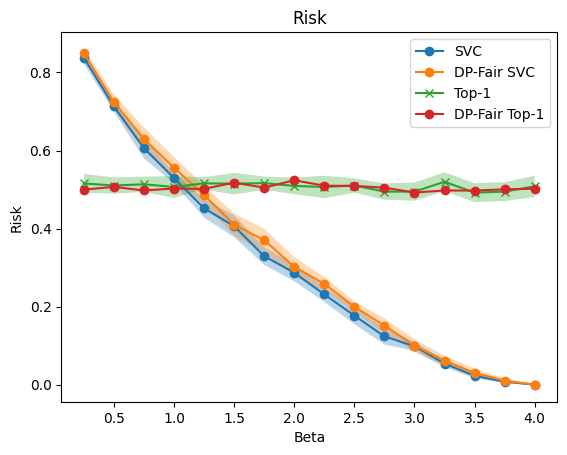

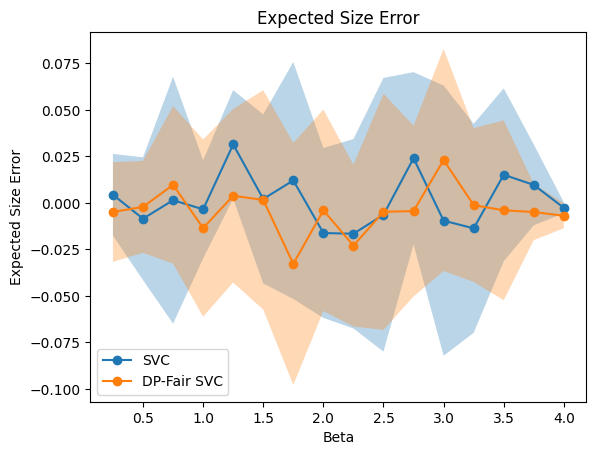

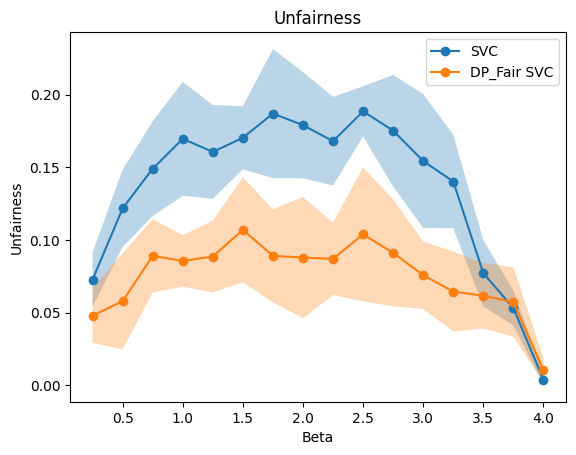

In [43]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risk_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_mean)-np.std(risks, axis=1), np.array(risks_mean)+np.std(risks, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risk_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risk_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes, axis=1), np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairnesses_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairnesses_mean)-np.std(unfairnesses, axis=1), np.array(unfairnesses_mean)+np.std(unfairnesses, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()

### Comparison Between Solver and Two-Step Methods

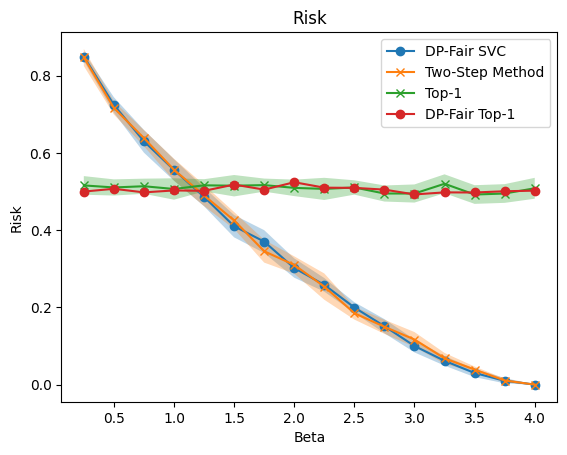

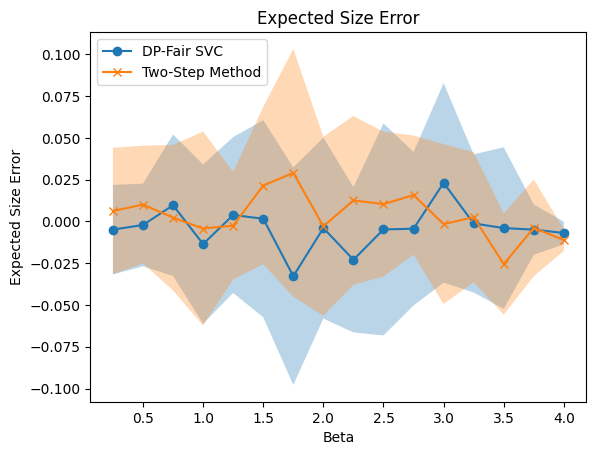

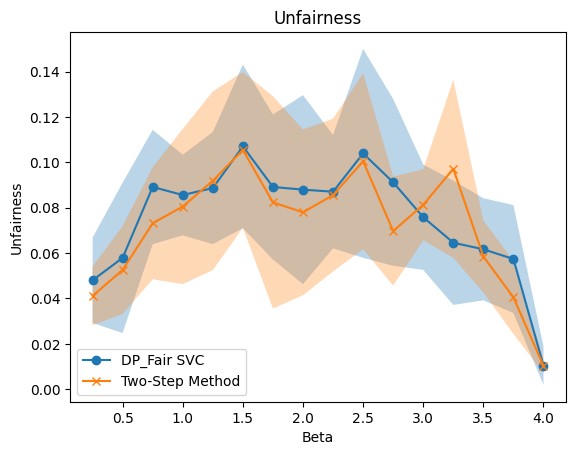

In [44]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_v2, label='Two-Step Method', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risk_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean_v2)-np.std(risks_fair_v2, axis=1), np.array(risks_fair_mean_v2)+np.std(risks_fair_v2, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risk_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risk_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair_v2, axis=1), np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean_v2, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean_v2)-np.std(unfairnesses_fair_v2, axis=1), np.array(unfairness_fair_mean_v2)+np.std(unfairnesses_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()

## CRIME Dataset

In [ ]:
# load data
import pandas as pd
keys = ["state",
"county",
"community",
"communityname",
"fold",
"population",
"householdsize",
"racepctblack",
"racePctWhite",
"racePctAsian",
"racePctHisp",
"agePct12t21",
"agePct12t29",
"agePct16t24",
"agePct65up",
"numbUrban",
"pctUrban",
"medIncome",
"pctWWage",
"pctWFarmSelf",
"pctWInvInc",
"pctWSocSec",
"pctWPubAsst",
"pctWRetire",
"medFamInc",
"perCapInc",
"whitePerCap",
"blackPerCap",
"indianPerCap",
"AsianPerCap",
"OtherPerCap",
"HispPerCap",
"NumUnderPov",
"PctPopUnderPov",
"PctLess9thGrade",
"PctNotHSGrad",
"PctBSorMore",
"PctUnemployed",
"PctEmploy",
"PctEmplManu",
"PctEmplProfServ",
"PctOccupManu",
"PctOccupMgmtProf",
"MalePctDivorce",
"MalePctNevMarr",
"FemalePctDiv",
"TotalPctDiv",
"PersPerFam",
"PctFam2Par",
"PctKids2Par",
"PctYoungKids2Par",
"PctTeen2Par",
"PctWorkMomYoungKids",
"PctWorkMom",
"NumIlleg",
"PctIlleg",
"NumImmig",
"PctImmigRecent",
"PctImmigRec5",
"PctImmigRec8",
"PctImmigRec10",
"PctRecentImmig",
"PctRecImmig5",
"PctRecImmig8",
"PctRecImmig10",
"PctSpeakEnglOnly",
"PctNotSpeakEnglWell",
"PctLargHouseFam",
"PctLargHouseOccup",
"PersPerOccupHous",
"PersPerOwnOccHous",
"PersPerRentOccHous",
"PctPersOwnOccup",
"PctPersDenseHous",
"PctHousLess3BR",
"MedNumBR",
"HousVacant",
"PctHousOccup",
"PctHousOwnOcc",
"PctVacantBoarded",
"PctVacMore6Mos",
"MedYrHousBuilt",
"PctHousNoPhone",
"PctWOFullPlumb",
"OwnOccLowQuart",
"OwnOccMedVal",
"OwnOccHiQuart",
"RentLowQ",
"RentMedian",
"RentHighQ",
"MedRent",
"MedRentPctHousInc",
"MedOwnCostPctInc",
"MedOwnCostPctIncNoMtg",
"NumInShelters",
"NumStreet",
"PctForeignBorn",
"PctBornSameState",
"PctSameHouse85",
"PctSameCity85",
"PctSameState85",
"LemasSwornFT",
"LemasSwFTPerPop",
"LemasSwFTFieldOps",
"LemasSwFTFieldPerPop",
"LemasTotalReq",
"LemasTotReqPerPop",
"PolicReqPerOffic",
"PolicPerPop",
"RacialMatchCommPol",
"PctPolicWhite",
"PctPolicBlack",
"PctPolicHisp",
"PctPolicAsian",
"PctPolicMinor",
"OfficAssgnDrugUnits",
"NumKindsDrugsSeiz",
"PolicAveOTWorked",
"LandArea",
"PopDens",
"PctUsePubTrans",
"PolicCars",
"PolicOperBudg",
"LemasPctPolicOnPatr",
"LemasGangUnitDeploy",
"LemasPctOfficDrugUn",
"PolicBudgPerPop",
"ViolentCrimesPerPop"]

data = pd.read_csv("./Data/communities.data", names=keys)
data

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,?,?,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,...,0.01,0.28,0.05,?,?,?,?,0.00,?,0.09
1990,6,?,?,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,...,0.02,0.37,0.20,?,?,?,?,0.00,?,0.45
1991,9,9,80070,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,...,0.08,0.32,0.18,0.08,0.06,0.78,0,0.91,0.28,0.23
1992,25,17,72600,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,...,0.03,0.38,0.33,0.02,0.02,0.79,0,0.22,0.18,0.19


In [ ]:
# Preprocessing the data
import numpy as np
data = data.drop(columns=["state", "county", "community", "communityname", "fold"])
for col in data.columns:
    if data[col].dtype == 'object':
        encoder = {k: v for v, k in enumerate(data[col].unique())}
        data[col] = data[col].map(encoder)
        data[col] = data[col].fillna(-1)  # Fill NaN values with -1
    # elif col == "ViolentCrimesPerPop":
    #     encoder = lambda x: x//0.2
    #     data[col] = data[col].apply(encoder)
    elif data[col].dtype == 'int64' or data[col].dtype == 'float64':
        data[col] = data[col].fillna(np.mean(data[col])) 
        if not data[col].max()<1 and not data[col].min()>-1:
            data[col] = (data[col] - data[col].mean()) / data[col].std()
K = 5
cuts = np.quantile(data["ViolentCrimesPerPop"], q = np.linspace(0, 1, num=K+1))
y_categ = np.zeros(data.shape[0], dtype=int)
for cl in range(K):
    index = (data["ViolentCrimesPerPop"] >= cuts[cl]) & (data["ViolentCrimesPerPop"] <= cuts[cl+1])
    y_categ[index] = cl
# print("stats of y (value, counts) :", np.unique(y_categ, return_counts=True))
data.loc[:, "ViolentCrimesPerPop"] = y_categ.astype(int)
S_vals = [-1,1]
S_col = "RaceMajorityWhite"
S = pd.DataFrame(2*(data["racePctWhite"] >= 0.5) - 1)
S.columns = [S_col]
data = pd.concat([data, S], axis=1)
data

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.26,0.20,0,0,0,0,0.32,0,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.02,0.12,0.45,1,1,1,1,0.00,1,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.01,0.21,0.02,1,1,1,1,0.00,1,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.02,0.39,0.28,1,1,1,1,0.00,1,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.04,0.09,0.02,1,1,1,1,0.00,1,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.01,0.28,0.05,1,1,1,1,0.00,1,0.09
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.02,0.37,0.20,1,1,1,1,0.00,1,0.45
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.08,0.32,0.18,19,2,14,2,0.91,17,0.23
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.03,0.38,0.33,11,6,10,2,0.22,19,0.19


### TOP-1 Classifier

In [111]:
lamb0 = np.array([np.log(1/K) for _ in range(K)])
# gamma0 = np.random.uniform(0, 1, size=K)
# initialGuess = np.concatenate([lamb0,gamma0])
initialGuess = lamb0
riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
risk_bayes_mean = []
risks_bayes = []
S_col = "RaceMajorityWhite"

estimator = GradientBoostingClassifier(n_estimators=50)

risk = np.zeros(Nrep)
# ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)


for b in range(1, beta_step*K+1):
    risks_bayes.append([])
    # unfairnesses_fair_top_1.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = param
        out = np.sum(np.mean(np.max(np.mean(S==1)*scoreBayes[S==1,]-lamb,  
                    axis = 1))
                    +np.mean(np.max(np.mean(S==-1)*scoreBayes[S==-1,]+lamb, axis = 1)))
        return(out)

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("ViolentCrimesPerPop", axis=1),
            data["ViolentCrimesPerPop"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.3,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = paramEstim.x

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        top_1  = np.zeros(len(Svalid))
        top_1[Svalid==1] = np.argmax(scoreNew[Svalid==1,], axis = 1).astype(int)
        top_1[Svalid==-1] = np.argmax(scoreNew[Svalid==-1,], axis = 1).astype(int)
        unfairness[m] = np.abs(np.max([np.mean(top_1[Svalid==1]==k) for k in range(K)]) - np.max([np.mean(top_1[Svalid==-1]==k) for k in range(K)]))
        risk[m] = np.mean(top_1!=Yvalid)
        risks_bayes[-1].append(risk[m])
        # unfairnesses_fair_top_1[-1].append(unfairness[m])
    risk_bayes_mean.append(np.mean(risks_bayes[-1]))


### DP-Fair TOP-1 Classifier

In [112]:
lamb0 = np.array([np.log(1/K) for _ in range(K)])
# gamma0 = np.random.uniform(0, 1, size=K)
# initialGuess = np.concatenate([lamb0,gamma0])
initialGuess = lamb0

# riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
# risk_bayes_mean = []
# risks_bayes = []

estimator = GradientBoostingClassifier(n_estimators=50)

risk = np.zeros(Nrep)
# ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair_top_1 = []
risks_fair_mean_top_1 = []
# sizes_fair = []
# sizes_fair_mean = []
unfairnesses_fair_top_1 = []
unfairness_fair_mean_top_1 = []

for b in range(1, beta_step*K+1):
    risks_fair_top_1.append([])
    # sizes_fair.append([])
    unfairnesses_fair_top_1.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = param
        out = np.sum(np.mean(np.max(np.mean(S==1)*scoreBayes[S==1,]-lamb,  
                    axis = 1))
                    +np.mean(np.max(np.mean(S==-1)*scoreBayes[S==-1,]+lamb, axis = 1)))
        return(out)

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("ViolentCrimesPerPop", axis=1),
            data["ViolentCrimesPerPop"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.3,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = paramEstim.x
        # tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        # ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        fair_top_1  = np.zeros(len(Svalid))
        # matSetValuedFair[Svalid==1, ] = (scoreNew[Svalid==1,]>= tt1)
        # matSetValuedFair[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= ttm1)
        fair_top_1[Svalid==1] = np.argmax(np.mean(S==1)*scoreNew[Svalid==1,] - lambStar, axis = 1).astype(int)
        fair_top_1[Svalid==-1] = np.argmax(np.mean(S==-1)*scoreNew[Svalid==-1,] + lambStar, axis = 1).astype(int)
        # print(fair_top_1)
        # ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.abs(np.max([np.mean(fair_top_1[Svalid==1]==k) for k in range(K)]) - np.max([np.mean(fair_top_1[Svalid==-1]==k) for k in range(K)]))
        risk[m] = np.mean(fair_top_1!=Yvalid.astype(int))

        risks_fair_top_1[-1].append(risk[m])
    #     sizes_fair[-1].append(ExpSize[m])
        unfairnesses_fair_top_1[-1].append(unfairness[m])
    risks_fair_mean_top_1.append(np.mean(risks_fair_top_1[-1]))
    # sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean_top_1.append(np.mean(unfairnesses_fair_top_1[-1]))

### Set-Valued Classifier (Unfair)

In [118]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks = []
risks_mean = []
sizes = []
sizes_mean = []
unfairnesses = []
unfairnesses_mean = []

for b in range(1, beta_step*K+1):
    risks.append([])
    sizes.append([])
    unfairnesses.append([])
    beta = b/beta_step

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("ViolentCrimesPerPop", axis=1),
            data["ViolentCrimesPerPop"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.5,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values
        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values
        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values
        
        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)

        scoreBayes = ScoreMixture(X, S, estimator)
        threshold = np.quantile(scoreBayes, 1-beta/K)

        T = np.mean(scoreBayes <= threshold, axis = 0)
        # tt1 = np.diag(np.quantile(scoreBayes[S==1,],T, axis = 0))
        # ttm1 = np.diag(np.quantile(scoreBayes[S==-1,],T, axis =0))
        tt1 = threshold
        ttm1 = threshold

        scorevalid = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scorevalid[Svalid==1,]>= tt1)
        matSetValuedFair[Svalid==-1, ] = (scorevalid[Svalid==-1,]>= ttm1)

        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[range(0,len(Svalid)),(Yvalid.astype(int))])

        risks[-1].append(risk[m])
        sizes[-1].append(ExpSize[m])
        unfairnesses[-1].append(unfairness[m])
    risks_mean.append(np.mean(risks[-1]))
    sizes_mean.append(np.mean(sizes[-1]))
    unfairnesses_mean.append(np.mean(unfairnesses[-1]))

### Fair Set-Valued Classifier (Solver)

In [114]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair = []
risks_fair_mean = []
sizes_fair = []
sizes_fair_mean = []
unfairnesses_fair = []
unfairness_fair_mean = []

for b in range(1, beta_step*K+1):
    risks_fair.append([])
    sizes_fair.append([])
    unfairnesses_fair.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = np.exp(param[0])
        gamma = param[1:(K+1)]
        out = np.sum(np.mean(np.maximum(np.mean(S==1)*(scoreBayes[S==1,]-lamb)-gamma,0), axis = 0)
                +np.mean(np.maximum(np.mean(S==-1)*(scoreBayes[S==-1,]-lamb)+gamma,0), axis =0)) + lamb*beta
        return(out)

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("ViolentCrimesPerPop", axis=1),
            data["ViolentCrimesPerPop"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.3,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = np.exp(paramEstim.x[0])
        tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scoreNew[Svalid==1,]>= tt1)
        matSetValuedFair[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= ttm1)

        
        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[range(0,len(Yvalid)),(Yvalid.astype(int))])

        risks_fair[-1].append(risk[m])
        sizes_fair[-1].append(ExpSize[m])
        unfairnesses_fair[-1].append(unfairness[m])
    risks_fair_mean.append(np.mean(risks_fair[-1]))
    sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean.append(np.mean(unfairnesses_fair[-1]))

### Fair Set-Valued Classifier (Two-Step Method)

In [115]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk_v2 = np.zeros(Nrep)
ExpSize_v2 = np.zeros(Nrep)
unfairness_v2 = np.zeros(Nrep)

risks_fair_v2 = []
risks_fair_mean_v2 = []
sizes_fair_v2 = []
sizes_fair_mean_v2 = []
unfairnesses_fair_v2 = []
unfairness_fair_mean_v2 = []

for b in range(1, beta_step*K+1):
    risks_fair_v2.append([])
    sizes_fair_v2.append([])
    unfairnesses_fair_v2.append([])
    beta = b/beta_step

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("ViolentCrimesPerPop", axis=1),
            data["ViolentCrimesPerPop"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.5,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values
        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values
        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values
        
        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)

        scoreBayes = ScoreMixture(X, S, estimator)
        threshold = np.quantile(scoreBayes, 1-beta/K)

        T = np.mean(scoreBayes <= threshold, axis = 0)
        tt1 = np.diag(np.quantile(scoreBayes[S==1,],T, axis = 0))
        ttm1 = np.diag(np.quantile(scoreBayes[S==-1,],T, axis =0))

        scorevalid = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scorevalid[Svalid==1,]>= tt1)
        matSetValuedFair[Svalid==-1, ] = (scorevalid[Svalid==-1,]>= ttm1)

        ExpSize_v2[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness_v2[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk_v2[m] = 1-np.mean(matSetValuedFair[range(0,len(Svalid)),(Yvalid.astype(int))])

        risks_fair_v2[-1].append(risk_v2[m])
        sizes_fair_v2[-1].append(ExpSize_v2[m])
        unfairnesses_fair_v2[-1].append(unfairness_v2[m])
    risks_fair_mean_v2.append(np.mean(risks_fair_v2[-1]))
    sizes_fair_mean_v2.append(np.mean(sizes_fair_v2[-1]))
    unfairness_fair_mean_v2.append(np.mean(unfairnesses_fair_v2[-1]))

### Comparison Between Unfair and Fair SVC

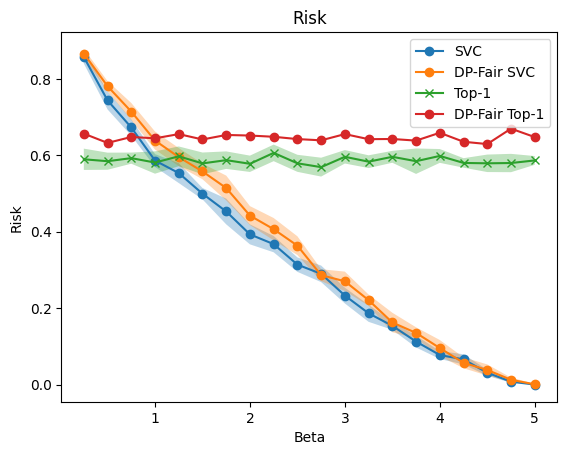

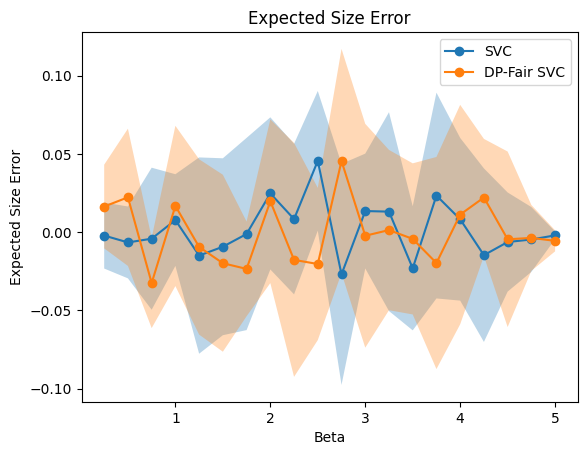

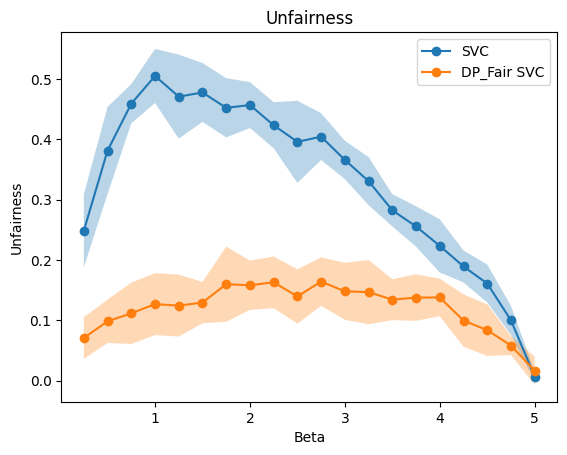

In [119]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risk_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_mean)-np.std(risks, axis=1), np.array(risks_mean)+np.std(risks, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risk_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risk_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes, axis=1), np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairnesses_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairnesses_mean)-np.std(unfairnesses, axis=1), np.array(unfairnesses_mean)+np.std(unfairnesses, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()

### Comparison Between Solver and Two-Step Methods

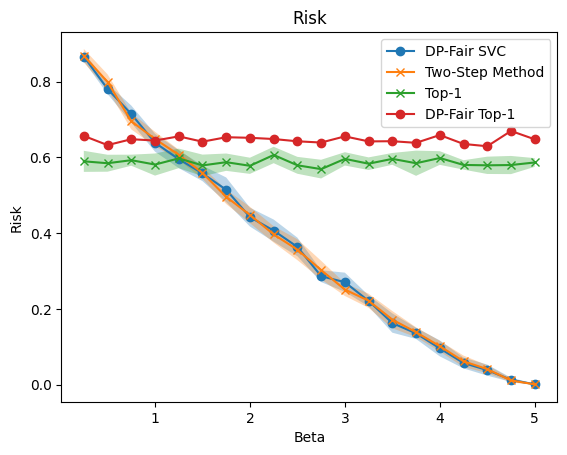

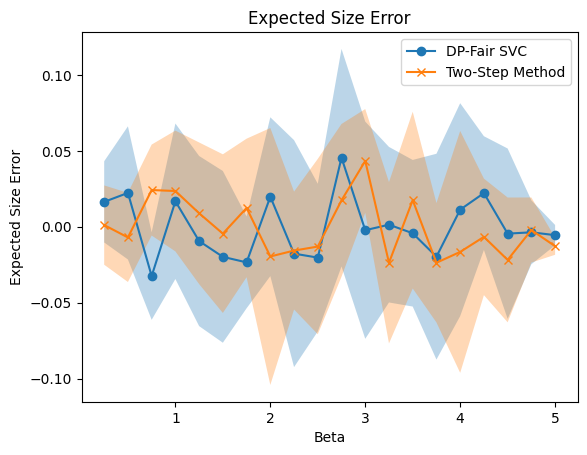

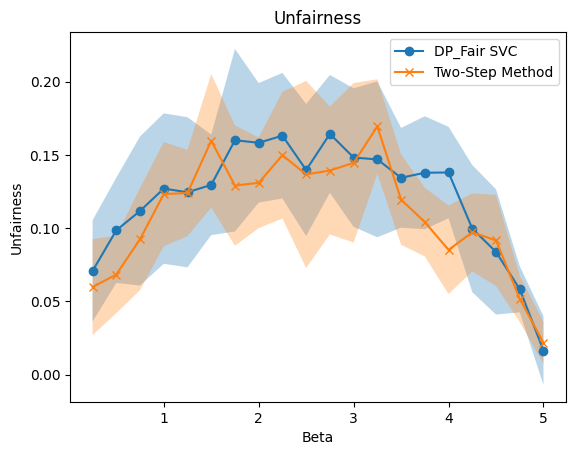

In [117]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_v2, label='Two-Step Method', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risk_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean_v2)-np.std(risks_fair_v2, axis=1), np.array(risks_fair_mean_v2)+np.std(risks_fair_v2, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risk_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risk_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair_v2, axis=1), np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean_v2, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean_v2)-np.std(unfairnesses_fair_v2, axis=1), np.array(unfairness_fair_mean_v2)+np.std(unfairnesses_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()

## Calibration de la taille N

In [37]:
from tqdm import tqdm

lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair = []
risks_fair_mean = []
sizes_fair = []
sizes_fair_mean = []
unfairnesses_fair = []
unfairnesses_unfair = []
unfairness_fair_mean = []
estimator = GradientBoostingClassifier(n_estimators=50)

# for b in range(1, beta_step*K+1):
for sampleSize in tqdm(np.linspace(10, 500, num=50)):
    risks_fair.append([])
    sizes_fair.append([])
    unfairnesses_fair.append([])
    # beta = b/beta_step
    beta = 1.25

    def LagrangianFunc(param):
        lamb = np.exp(param[0])
        gamma = param[1:(K+1)]
        out = np.sum(np.mean(np.maximum(np.mean(S==1)*(scoreBayes[S==1,]-lamb)-gamma,0), axis = 0)
                +np.mean(np.maximum(np.mean(S==-1)*(scoreBayes[S==-1,]-lamb)+gamma,0), axis =0)) + lamb*beta
        return(out)
    # print("Doing N: ", sampleSize)
    for m in range(Nrep):

        # X_train, Xvalid, y_train, Yvalid = train_test_split(
        #     data.drop("ViolentCrimesPerPop", axis=1),
        #     data["ViolentCrimesPerPop"],
        #     test_size=0.15,
        # )

        # X_pk, X, y_pk, Y = train_test_split(
        #     X_train,
        #     y_train,
        #     test_size=percent,
        # )

        # S_train = X_train[S_col]
        # S_pk = X_pk[S_col]
        # S = X[S_col]
        # Svalid = Xvalid[S_col]

        # X_train = X_train.drop(columns = [S_col]).values
        # X = X.drop(columns = [S_col]).values
        # X_pk = X_pk.drop(columns = [S_col]).values

        # Xvalid = Xvalid.drop(columns = [S_col]).values
        # Yvalid = Yvalid.values
        # Y = Y.values
        # y_train = y_train.values
        # y_pk = y_pk.values

        # S_train = S_train.values
        # Svalid = Svalid.values
        # S_pk = S_pk.values
        # S = S.values

        # X_pk,S_pk,y_pk = getSample(int(sampleSize*(1-percent)), muVec, sigma, K, pY)
        X,S,Y = getSample(int(sampleSize), muVec, sigma, K, pY)

        # data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        # estimator.fit(data_train_pk, y_pk)
        # scoreBayes = ScoreMixture(X, S, estimator)
        scoreBayes = ScoreMixture(X, S, muVec, sigma, K, pY, pSgivenY)

        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        threshold = np.quantile(scoreBayes, 1-beta/K)

        lambStar = np.exp(paramEstim.x[0])
        tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)

        Xvalid,Svalid,Yvalid = getSample(int(sampleSize/2), muVec, sigma, K, pY)

        # scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        scoreNew = ScoreMixture(Xvalid, Svalid, muVec, sigma, K, pY, pSgivenY)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scoreNew[Svalid==1,]>= tt1)
        matSetValuedFair[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= ttm1)

        # matSetValued  = np.zeros((len(Svalid),K))
        # matSetValued[Svalid==1, ] = (scoreNew[Svalid==1,]>= threshold)
        # matSetValued[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= threshold)
        
        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[:,(Yvalid-1)])

        # ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        # unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        # risk[m] = 1-np.mean(matSetValuedFair[:,(Yvalid-1)])

        risks_fair[-1].append(risk[m])
        sizes_fair[-1].append(ExpSize[m])

        unfairnesses_fair[-1].append(unfairness[m])
    risks_fair_mean.append(np.mean(risks_fair[-1]))
    sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean.append(np.mean(unfairnesses_fair[-1]))

  0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_23850/3050920558.py:29: RuntimeWarning: overflow encountered in exp
  lamb = np.exp(param[0])
/home/ecohen/PhD/Set-Valued_Classification_Under_Fairness_Constraints/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
100%|██████████| 50/50 [00:12<00:00,  3.94it/s]


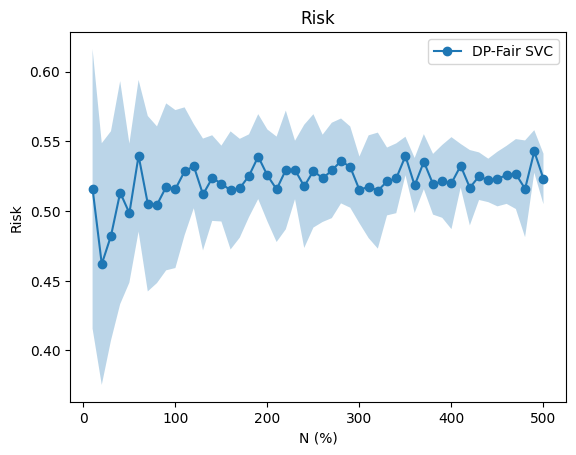

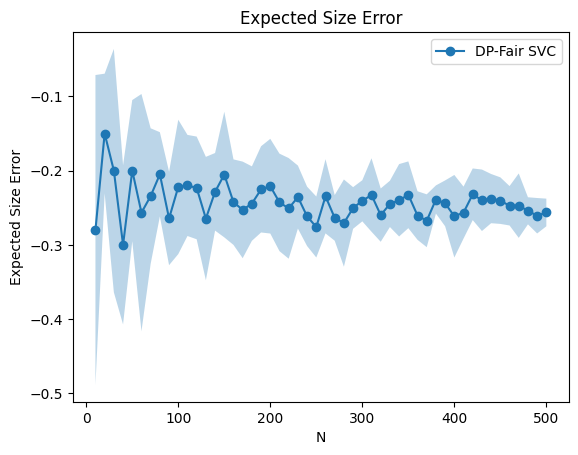

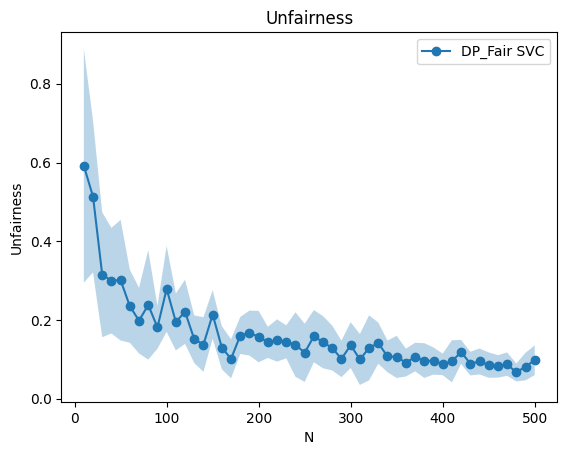

In [38]:
# plt.plot(np.linspace(10, 500, num=50), risks_mean, label='SVC', marker='o')
plt.plot(np.linspace(10, 500, num=50), risks_fair_mean, label='DP-Fair SVC', marker='o')
# plt.plot(np.linspace(10, 500, num=50), risk_bayes_mean, label='Top-1', marker='x')
# plt.fill_between(np.linspace(10, 500, num=50), np.array(risks_mean)-np.std(risks, axis=1), np.array(risks_mean)+np.std(risks, axis=1), alpha=0.3)
plt.fill_between(np.linspace(10, 500, num=50), np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
# plt.fill_between(np.linspace(10, 500, num=50), np.array(risk_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risk_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.xlabel('N (%)')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
# plt.plot(np.linspace(10, 500, num=50), np.array(sizes_mean)-1.5, label='SVC', marker='o')
plt.plot(np.linspace(10, 500, num=50), np.array(sizes_fair_mean)-1.5, label='DP-Fair SVC', marker='o')
# plt.fill_between(np.linspace(10, 500, num=50), np.array(sizes_mean)-1.5-np.std(sizes, axis=1), np.array(sizes_mean)-1.5+np.std(sizes, axis=1), alpha=0.3)
plt.fill_between(np.linspace(10, 500, num=50), np.array(sizes_fair_mean)-1.5-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-1.5+np.std(sizes_fair, axis=1), alpha=0.3)
plt.xlabel('N')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
# plt.plot(np.linspace(10, 500, num=50), unfairnesses_mean, label='SVC', marker='o')
plt.plot(np.linspace(10, 500, num=50), unfairness_fair_mean, label='DP_Fair SVC', marker='o')
# plt.fill_between(np.linspace(10, 500, num=50), np.array(unfairnesses_mean)-np.std(unfairnesses, axis=1), np.array(unfairnesses_mean)+np.std(unfairnesses, axis=1), alpha=0.3)
plt.fill_between(np.linspace(10, 500, num=50), np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.xlabel('N')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()

## Adult Dataset

In [ ]:
data = pd.read_csv("./Data/adult/adult.data", names = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"], delimiter = ",")
# data.drop(index=0, inplace=True)
K = 2
S_col = "sex"
for col in data.columns:
    if data[col].dtype == 'object':
        encoder = {k: v for v, k in enumerate(data[col].unique())}
        data[col] = data[col].map(encoder)
        data[col] = data[col].fillna(-1)  # Fill NaN values with -1
    # elif col == "ViolentCrimesPerPop":
    #     encoder = lambda x: x//0.2
    #     data[col] = data[col].apply(encoder)
    elif data[col].dtype == 'int64' or data[col].dtype == 'float64':
        data[col] = data[col].fillna(np.mean(data[col])) 
        if not data[col].max()<1 and not data[col].min()>-1:
            data[col] = (data[col] - data[col].mean()) / data[col].std()
data.loc[:, "sex"] = 2*data["sex"].astype(int) - 1
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,0,77516,0,13,0,0,0,0,-1,2174,0,40,0,0
1,50,1,83311,0,13,1,1,1,0,-1,0,0,13,0,0
2,38,2,215646,1,9,2,2,0,0,-1,0,0,40,0,0
3,53,2,234721,2,7,1,2,1,1,-1,0,0,40,0,0
4,28,2,338409,0,13,1,3,2,1,1,0,0,40,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,2,257302,6,12,1,10,2,0,1,0,0,38,0,0
32557,40,2,154374,1,9,1,9,1,0,-1,0,0,40,0,1
32558,58,2,151910,1,9,6,0,4,0,1,0,0,40,0,0
32559,22,2,201490,1,9,0,0,3,0,-1,0,0,20,0,0


### TOP-1 Classifier

In [ ]:
lamb0 = np.array([np.log(1/K) for _ in range(K)])
# gamma0 = np.random.uniform(0, 1, size=K)
# initialGuess = np.concatenate([lamb0,gamma0])
initialGuess = lamb0

S_col = "sex"
# riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
# risk_bayes_mean = []
# risks_bayes = []
beta_step = 20

estimator = GradientBoostingClassifier(n_estimators=50)

risk = np.zeros(Nrep)
# ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_bayes = []
risks_bayes_mean = []
# sizes_fair = []
# sizes_fair_mean = []
# unfairnesses_fair_top_1 = []
# unfairness_fair_mean_top_1 = []

for b in range(1, beta_step*K+1):
    risks_bayes.append([])
    # sizes_fair.append([])
    # unfairnesses_fair_top_1.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = param
        out = np.sum(np.mean(np.max(np.mean(S==1)*scoreBayes[S==1,]-lamb,  
                    axis = 1))
                    +np.mean(np.max(np.mean(S==-1)*scoreBayes[S==-1,]+lamb, axis = 1)))
        return(out)

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("income", axis=1),
            data["income"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.3,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = paramEstim.x
        # tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        # ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        fair_top_1  = np.zeros(len(Svalid))
        # matSetValuedFair[Svalid==1, ] = (scoreNew[Svalid==1,]>= tt1)
        # matSetValuedFair[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= ttm1)
        fair_top_1[Svalid==1] = np.argmax(scoreNew[Svalid==1,], axis = 1).astype(int)
        fair_top_1[Svalid==-1] = np.argmax(scoreNew[Svalid==-1,], axis = 1).astype(int)
        # print(fair_top_1)
        # ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.abs(np.max([np.mean(fair_top_1[Svalid==1]==k) for k in range(K)]) - np.max([np.mean(fair_top_1[Svalid==-1]==k) for k in range(K)]))
        risk[m] = np.mean(fair_top_1!=Yvalid.astype(int))

        risks_bayes[-1].append(risk[m])
    #     sizes_fair[-1].append(ExpSize[m])
        # unfairnesses_fair_top_1[-1].append(unfairness[m])
    risks_bayes_mean.append(np.mean(risks_bayes[-1]))
    # sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    # unfairness_fair_mean_top_1.append(np.mean(unfairnesses_fair_top_1[-1]))

### DP-Fair TOP-1 Classifier

In [53]:
lamb0 = np.array([np.log(1/K) for _ in range(K)])
# gamma0 = np.random.uniform(0, 1, size=K)
# initialGuess = np.concatenate([lamb0,gamma0])
initialGuess = lamb0

# riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
# risk_bayes_mean = []
# risks_bayes = []

estimator = GradientBoostingClassifier(n_estimators=20)

risk = np.zeros(Nrep)
# ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair_top_1 = []
risks_fair_mean_top_1 = []
# sizes_fair = []
# sizes_fair_mean = []
unfairnesses_fair_top_1 = []
unfairness_fair_mean_top_1 = []

for b in range(1, beta_step*K+1):
    risks_fair_top_1.append([])
    # sizes_fair.append([])
    unfairnesses_fair_top_1.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = param
        out = np.sum(np.mean(np.max(np.mean(S==1)*scoreBayes[S==1,]-lamb,  
                    axis = 1))
                    +np.mean(np.max(np.mean(S==-1)*scoreBayes[S==-1,]+lamb, axis = 1)))
        return(out)

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("income", axis=1),
            data["income"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.3,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = paramEstim.x
        # tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        # ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        fair_top_1  = np.zeros(len(Svalid))
        # matSetValuedFair[Svalid==1, ] = (scoreNew[Svalid==1,]>= tt1)
        # matSetValuedFair[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= ttm1)
        fair_top_1[Svalid==1] = np.argmax(np.mean(S==1)*scoreNew[Svalid==1,] - lambStar, axis = 1).astype(int)
        fair_top_1[Svalid==-1] = np.argmax(np.mean(S==-1)*scoreNew[Svalid==-1,] + lambStar, axis = 1).astype(int)
        # print(fair_top_1)
        # ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.abs(np.max([np.mean(fair_top_1[Svalid==1]==k) for k in range(K)]) - np.max([np.mean(fair_top_1[Svalid==-1]==k) for k in range(K)]))
        risk[m] = np.mean(fair_top_1!=Yvalid.astype(int))

        risks_fair_top_1[-1].append(risk[m])
    #     sizes_fair[-1].append(ExpSize[m])
        unfairnesses_fair_top_1[-1].append(unfairness[m])
    risks_fair_mean_top_1.append(np.mean(risks_fair_top_1[-1]))
    # sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean_top_1.append(np.mean(unfairnesses_fair_top_1[-1]))

### Set-Valued Classifier (Unfair)

In [54]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks = []
risks_mean = []
sizes = []
sizes_mean = []
unfairnesses = []
unfairnesses_mean = []

for b in range(1, beta_step*K+1):
    risks.append([])
    sizes.append([])
    unfairnesses.append([])
    beta = b/beta_step

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("income", axis=1),
            data["income"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.5,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values
        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values
        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values
        
        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)

        scoreBayes = ScoreMixture(X, S, estimator)
        threshold = np.quantile(scoreBayes, 1-beta/K)

        T = np.mean(scoreBayes <= threshold, axis = 0)
        # tt1 = np.diag(np.quantile(scoreBayes[S==1,],T, axis = 0))
        # ttm1 = np.diag(np.quantile(scoreBayes[S==-1,],T, axis =0))
        tt1 = threshold
        ttm1 = threshold

        scorevalid = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scorevalid[Svalid==1,]>= tt1)
        matSetValuedFair[Svalid==-1, ] = (scorevalid[Svalid==-1,]>= ttm1)

        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[range(0,len(Svalid)),(Yvalid.astype(int))])

        risks[-1].append(risk[m])
        sizes[-1].append(ExpSize[m])
        unfairnesses[-1].append(unfairness[m])
    risks_mean.append(np.mean(risks[-1]))
    sizes_mean.append(np.mean(sizes[-1]))
    unfairnesses_mean.append(np.mean(unfairnesses[-1]))

### Fair Set-Valued Classifier (Solver)

In [55]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

# riskBayes = np.zeros(Nrep)
# risks = []
# risks_mean = []
# risk = np.zeros(Nrep)
# sizes = []
# sizes_mean = []
# ExpSize = np.zeros(Nrep)
# unfairnesses = []
# unfairnesses_mean = []
# unfairness = np.zeros(Nrep)
# risk_bayes_mean = []
# risks_bayes = []

estimator = GradientBoostingClassifier(n_estimators=50)

risk = np.zeros(Nrep)
ExpSize = np.zeros(Nrep)
unfairness = np.zeros(Nrep)

risks_fair = []
risks_fair_mean = []
sizes_fair = []
sizes_fair_mean = []
unfairnesses_fair = []
unfairness_fair_mean = []

for b in range(1, beta_step*K+1):
    risks_fair.append([])
    sizes_fair.append([])
    unfairnesses_fair.append([])
    beta = b/beta_step

    def LagrangianFunc(param):
        lamb = np.exp(param[0])
        gamma = param[1:(K+1)]
        out = np.sum(np.mean(np.maximum(np.mean(S==1)*(scoreBayes[S==1,]-lamb)-gamma,0), axis = 0)
                +np.mean(np.maximum(np.mean(S==-1)*(scoreBayes[S==-1,]-lamb)+gamma,0), axis =0)) + lamb*beta
        return(out)

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("income", axis=1),
            data["income"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.3,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values

        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values

        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values

        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)
        scoreBayes = ScoreMixture(X, S, estimator)
        
        paramEstim =  minimize(LagrangianFunc, initialGuess, method = "L-BFGS-B")

        lambStar = np.exp(paramEstim.x[0])
        tt1 = lambStar + paramEstim.x[1:(K+1)]/np.mean(S==1)
        ttm1= lambStar - paramEstim.x[1:(K+1)]/np.mean(S==-1)

        scoreNew = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scoreNew[Svalid==1,]>= tt1)
        matSetValuedFair[Svalid==-1, ] = (scoreNew[Svalid==-1,]>= ttm1)

        
        ExpSize[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk[m] = 1-np.mean(matSetValuedFair[range(0,len(Yvalid)),(Yvalid.astype(int))])

        risks_fair[-1].append(risk[m])
        sizes_fair[-1].append(ExpSize[m])
        unfairnesses_fair[-1].append(unfairness[m])
    risks_fair_mean.append(np.mean(risks_fair[-1]))
    sizes_fair_mean.append(np.mean(sizes_fair[-1]))
    unfairness_fair_mean.append(np.mean(unfairnesses_fair[-1]))

### Fair Set-Valued Classifier (Two-Step Method)

In [56]:
lamb0 = np.array([np.log(1/K)])
gamma0 = np.random.uniform(0, 1, size=K)
initialGuess = np.concatenate([lamb0,gamma0])

risk_v2 = np.zeros(Nrep)
ExpSize_v2 = np.zeros(Nrep)
unfairness_v2 = np.zeros(Nrep)

risks_fair_v2 = []
risks_fair_mean_v2 = []
sizes_fair_v2 = []
sizes_fair_mean_v2 = []
unfairnesses_fair_v2 = []
unfairness_fair_mean_v2 = []

for b in range(1, beta_step*K+1):
    risks_fair_v2.append([])
    sizes_fair_v2.append([])
    unfairnesses_fair_v2.append([])
    beta = b/beta_step

    for m in range(Nrep):

        X_train, Xvalid, y_train, Yvalid = train_test_split(
            data.drop("income", axis=1),
            data["income"],
            test_size=0.2,
        )

        X_pk, X, y_pk, Y = train_test_split(
            X_train,
            y_train,
            test_size=0.5,
        )

        S_train = X_train[S_col]
        S_pk = X_pk[S_col]
        S = X[S_col]
        Svalid = Xvalid[S_col]

        X_train = X_train.drop(columns = [S_col]).values
        X = X.drop(columns = [S_col]).values
        X_pk = X_pk.drop(columns = [S_col]).values
        Xvalid = Xvalid.drop(columns = [S_col]).values
        Yvalid = Yvalid.values
        Y = Y.values
        y_train = y_train.values
        y_pk = y_pk.values
        S_train = S_train.values
        Svalid = Svalid.values
        S_pk = S_pk.values
        S = S.values
        
        data_train_pk = np.concatenate((X_pk, S_pk.reshape(-1, 1)), axis=1)
        estimator.fit(data_train_pk, y_pk)

        scoreBayes = ScoreMixture(X, S, estimator)
        threshold = np.quantile(scoreBayes, 1-beta/K)

        T = np.mean(scoreBayes <= threshold, axis = 0)
        tt1 = np.diag(np.quantile(scoreBayes[S==1,],T, axis = 0))
        ttm1 = np.diag(np.quantile(scoreBayes[S==-1,],T, axis =0))

        scorevalid = ScoreMixture(Xvalid, Svalid, estimator)
        matSetValuedFair  = np.zeros((len(Svalid),K))
        matSetValuedFair[Svalid==1, ] = (scorevalid[Svalid==1,]>= tt1)
        matSetValuedFair[Svalid==-1, ] = (scorevalid[Svalid==-1,]>= ttm1)

        ExpSize_v2[m] = np.mean(np.sum(matSetValuedFair,axis=1))
        unfairness_v2[m] = np.max(np.abs(np.mean(matSetValuedFair[Svalid==1,:], axis=0)- np.mean(matSetValuedFair[Svalid==-1,:], axis=0)))
        risk_v2[m] = 1-np.mean(matSetValuedFair[range(0,len(Svalid)),(Yvalid.astype(int))])

        risks_fair_v2[-1].append(risk_v2[m])
        sizes_fair_v2[-1].append(ExpSize_v2[m])
        unfairnesses_fair_v2[-1].append(unfairness_v2[m])
    risks_fair_mean_v2.append(np.mean(risks_fair_v2[-1]))
    sizes_fair_mean_v2.append(np.mean(sizes_fair_v2[-1]))
    unfairness_fair_mean_v2.append(np.mean(unfairnesses_fair_v2[-1]))

### Comparison Between Unfair and Fair SVC

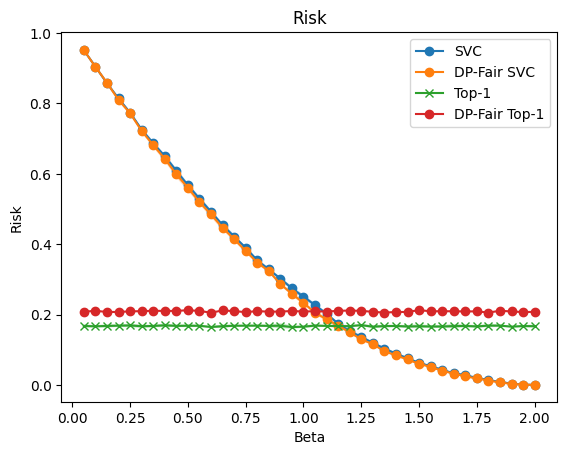

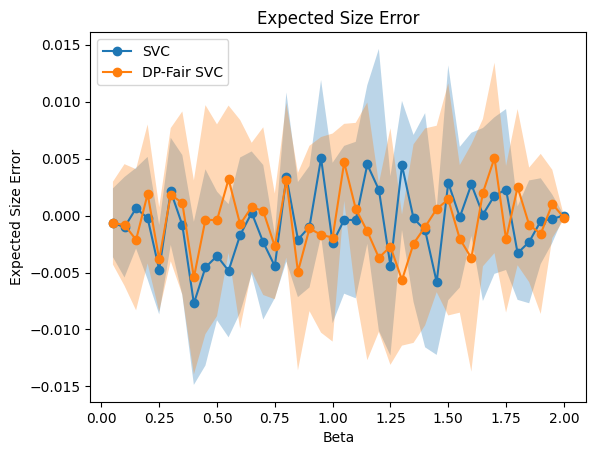

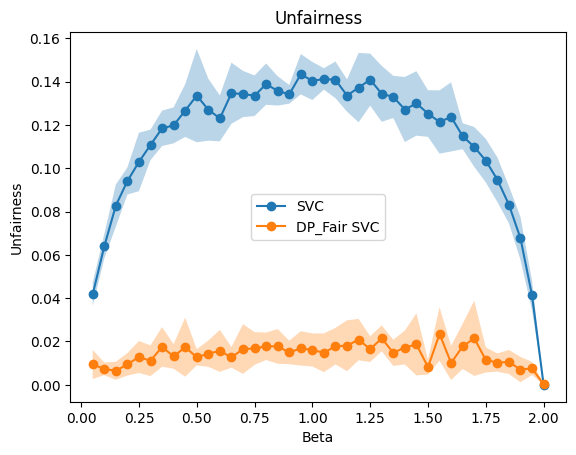

In [57]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_mean)-np.std(risks, axis=1), np.array(risks_mean)+np.std(risks, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risks_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes, axis=1), np.array(sizes_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairnesses_mean, label='SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairnesses_mean)-np.std(unfairnesses, axis=1), np.array(unfairnesses_mean)+np.std(unfairnesses, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()

### Comparison Between Solver and Two-Step Methods

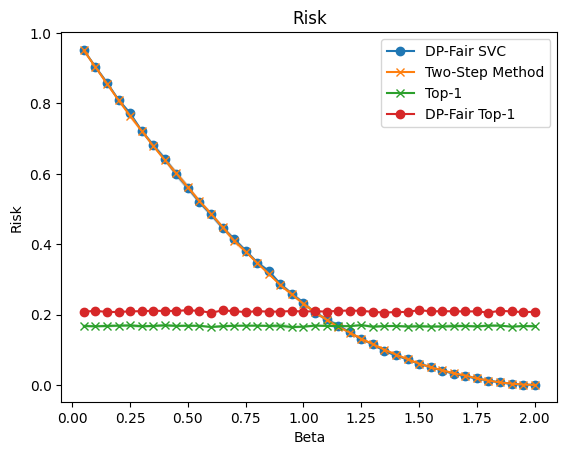

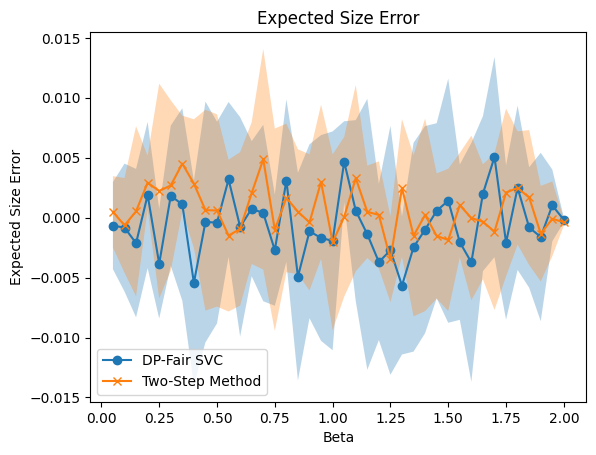

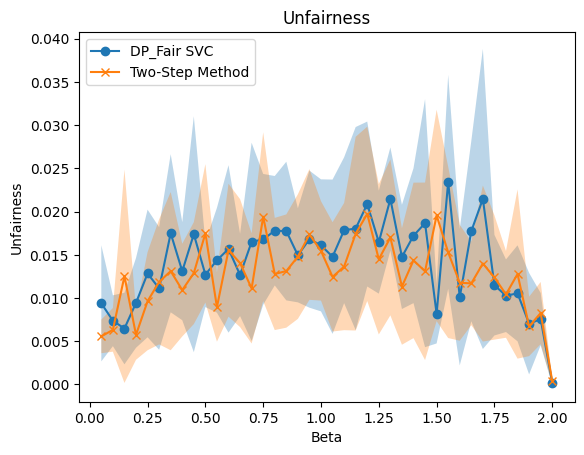

In [58]:
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_v2, label='Two-Step Method', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_bayes_mean, label='Top-1', marker='x')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, risks_fair_mean_top_1, label='DP-Fair Top-1', marker='o')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean)-np.std(risks_fair, axis=1), np.array(risks_fair_mean)+np.std(risks_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_fair_mean_v2)-np.std(risks_fair_v2, axis=1), np.array(risks_fair_mean_v2)+np.std(risks_fair_v2, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(risks_bayes_mean)-np.std(risks_bayes, axis=1), np.array(risks_bayes_mean)+np.std(risks_bayes, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Risk')
plt.title('Risk')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step, label='DP-Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair, axis=1), np.array(sizes_fair_mean)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step-np.std(sizes_fair_v2, axis=1), np.array(sizes_fair_mean_v2)-np.arange(1, beta_step*K+1)/beta_step+np.std(sizes_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Expected Size Error')
plt.title('Expected Size Error')
plt.legend()
plt.show()
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean, label='DP_Fair SVC', marker='o')
plt.plot(np.arange(1, beta_step*K+1)/beta_step, unfairness_fair_mean_v2, label='Two-Step Method', marker='x')
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean)-np.std(unfairnesses_fair, axis=1), np.array(unfairness_fair_mean)+np.std(unfairnesses_fair, axis=1), alpha=0.3)
plt.fill_between(np.arange(1, beta_step*K+1)/beta_step, np.array(unfairness_fair_mean_v2)-np.std(unfairnesses_fair_v2, axis=1), np.array(unfairness_fair_mean_v2)+np.std(unfairnesses_fair_v2, axis=1), alpha=0.3)
plt.xlabel('Beta')
plt.ylabel('Unfairness')
plt.title('Unfairness')
plt.legend()
plt.show()